<small>
Introducción a la Ciencia de Datos | Posgrado en Ciencias de la Computación — CICESE  
Práctica 2: Procesamiento de datasets
</small>

---

### Conjunto de datos de PCOS

Como continuacion de la practica #1, en esta se analizara la informacion y se complementara con un procesamiento del dataset. 

El dataset seleccionado para realizar esto aunque sea del mismo tema que en la Practica-I se opto por cambiar de dataset.

De igual manera este dataset fue recuperado de Kaggle, en donde se especifica que el autor fue "Michael Mendiola Sy" (Mendiola Sy, s.f.). Este dataset fue recolectado y armado con informacion resultante de ensayos y estudios realizados en Filipinas, no se incluyen nombres de pacientes y fue unicamente tratado para propositos educativos y de investigacion.

### informacion del dataset:

- **Dataset:** PCOS Clinical Dataset
- **Autor:** Michael Mendiola Sy
- **Fuente:** [Kaggle](https://www.kaggle.com/datasets/michaelmendiolasy/pcos-clinical-dataset)
- **Licencia:** [Creative Commons Atribución 4.0 Internacional (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/)
- **Fecha de acceso:** 29 de Septiembre del 2026

### Estructura del dataset

El archivo `data without infertility _final.csv` contiene **541 filas** (una por paciente) y **43 columnas**. La variable objetivo es `PCOS (Y/N)` (0 = sin PCOS, 1 = con PCOS). La columna 43 (`Unnamed: 42`) es un artefacto de exportacion sin nombre, practicamente vacia.

| Grupo | Columnas | Cantidad |
|---|---|---|
| Identificacion | `Sl. No`, `Patient File No.` | 2 |
| Variable objetivo | `PCOS (Y/N)` | 1 |
| Datos generales y antropometricos | `Age (yrs)`, `Weight (Kg)`, `Height(Cm)`, `BMI`, `Blood Group`, `Hip(inch)`, `Waist(inch)`, `Waist:Hip Ratio` | 8 |
| Signos vitales | `Pulse rate(bpm)`, `RR (breaths/min)`, `BP _Systolic (mmHg)`, `BP _Diastolic (mmHg)` | 4 |
| Ciclo menstrual e historia reproductiva | `Cycle(R/I)`, `Cycle length(days)`, `Marraige Status (Yrs)`, `Pregnant(Y/N)`, `No. of aborptions` | 5 |
| Hormonas y laboratorio | `FSH(mIU/mL)`, `LH(mIU/mL)`, `FSH/LH`, `TSH (mIU/L)`, `AMH(ng/mL)`, `PRL(ng/mL)`, `Vit D3 (ng/mL)`, `PRG(ng/mL)`, `RBS(mg/dl)`, `Hb(g/dl)` | 10 |
| Sintomas y habitos (Y/N) | `Weight gain(Y/N)`, `hair growth(Y/N)`, `Skin darkening (Y/N)`, `Hair loss(Y/N)`, `Pimples(Y/N)`, `Fast food (Y/N)`, `Reg.Exercise(Y/N)` | 7 |
| Ultrasonido | `Follicle No. (L)`, `Follicle No. (R)`, `Avg. F size (L) (mm)`, `Avg. F size (R) (mm)`, `Endometrium (mm)` | 5 |
| Sin nombre | `Unnamed: 42` | 1 |
| **Total** | | **43** |

**Modificaciones:** los datos originales fueron procesados en este notebook (eliminacion de columnas, correccion de tipos, imputacion de valores faltantes y tratamiento de valores atipicos).
Los archivos originales no fueron alterados.

## 1. Carga de datos y librerias

Se importan las librerías necesarias para el analisis (`pandas`, `numpy`, `seaborn` y `matplotlib`) y se carga el dataset. Ademas, se eliminan los espacios sobrantes al inicio y al final de los nombres de las columnas para evitar errores al referenciarlas.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("../../Datos/data without infertility _final.csv")
df.columns = df.columns.str.strip()
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 42
0,1,10001,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,10002,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,10003,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,10004,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,10005,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


---

## 2. EDA inicial: conocer los datos

En esta seccion solo se **detectan** los problemas del dataset. Las correcciones se hacen en la seccion 3.

Antes de modificar cualquier dato es necesario entender como viene el dataset original: que tipo de informacion contiene cada columna, si hay datos faltantes o mal capturados y como se distribuye la variable objetivo. Separar la deteccion de la correccion permite justificar cada cambio que se haga despues y evita alterar datos sin una razon clara.

La seccion se divide en tres partes:

| Apartado | Que se hara | Por que |
|---|---|---|
| **2.1 Estructura general** | Revisar tipos de dato, valores no nulos (`info`), dimensiones (`shape`) y estadisticas descriptivas (`describe`). | Para tener una primera idea del tamano del dataset, detectar columnas con tipo incorrecto y ver rangos de valores sospechosos (minimos o maximos fuera de lo esperado). |
| **2.2 Calidad de los datos** | Buscar valores faltantes, registros duplicados, columnas con texto donde deberia haber numeros, categorias invalidas y comprobar que las variables compuestas (`BMI`, `Waist:Hip Ratio`, `FSH/LH`) esten bien calculadas. | Los errores de captura o de calculo afectan directamente el analisis y cualquier modelo que se entrene despues; es mejor identificarlos todos antes de limpiar. |
| **2.3 Variable objetivo** | Contar cuantas pacientes hay con y sin PCOS. | Saber si las clases estan balanceadas influye en decisiones posteriores, como preferir imputar en lugar de eliminar registros o aplicar aumento de datos. |

Al final de 2.2 se presenta una lista con todos los problemas encontrados, que sirve como guia para la seccion 3.

---

## 2.1 Estructura general

Se revisa la forma general del dataset: tipos de dato y valores no nulos por columna (`info`), numero de filas y columnas (`shape`) y estadísticas descriptivas de las variables numéricas (`describe`).

A simple vista, se observa que para la columna `AMH(ng/mL)` y `Unnamed: 42` deberia contener valores numericos y estan como texto. Para `Unnamed: 42` lo mas probable es que sea un error ya que el nombre de la etiqueta no aporta informacion.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sl. No                 541 non-null    int64  
 1   Patient File No.       541 non-null    int64  
 2   PCOS (Y/N)             541 non-null    int64  
 3   Age (yrs)              541 non-null    int64  
 4   Weight (Kg)            541 non-null    float64
 5   Height(Cm)             541 non-null    float64
 6   BMI                    541 non-null    float64
 7   Blood Group            541 non-null    int64  
 8   Pulse rate(bpm)        541 non-null    int64  
 9   RR (breaths/min)       541 non-null    int64  
 10  Hb(g/dl)               541 non-null    float64
 11  Cycle(R/I)             541 non-null    int64  
 12  Cycle length(days)     541 non-null    int64  
 13  Marraige Status (Yrs)  540 non-null    float64
 14  Pregnant(Y/N)          541 non-null    int64  
 15  No. of aborptions

---

### Dimensiones del dataset

El dataset tiene **541 filas** (una por paciente) y **43 columnas**, lo cual coincide con lo descrito en la estructura del dataset.

In [3]:
df.shape

(541, 43)

---

### Estadisticas descriptivas

- El resumen muestra **41 de las 43 columnas**, ya que `AMH(ng/mL)` y `Unnamed: 42` estan guardadas como texto y no se incluyen. Esto confirma que `AMH(ng/mL)` tiene un problema de tipo de dato.
- `Fast food (Y/N)` tiene un conteo de 540 en lugar de 541, lo que indica un valor faltante.
- La media de `PCOS (Y/N)` es 0.327, es decir, aproximadamente el **33% de las pacientes tiene PCOS**.
- La edad va de 20 a 48 años y el BMI de 12.4 a 38.9, rangos posibles fisiologicamente.
- Hay valores minimos imposibles en signos vitales: `Pulse rate(bpm)` = 13, `BP _Systolic (mmHg)` = 12 y `BP _Diastolic (mmHg)` = 8, probablemente errores de captura (por ejemplo, un digito faltante).
- Variables de ultrasonido como `Avg. F size (L) (mm)`, `Avg. F size (R) (mm)` y `Endometrium (mm)` tienen minimos de 0, lo cual puede indicar ausencia de foliculos o datos no registrados.

In [4]:
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,10271.000000,0.327172,31.430684,59.637153,156.484835,24.311285,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.056399,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,10001.000000,0.000000,20.000000,31.000000,137.000000,12.417882,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,10136.000000,0.000000,28.000000,52.000000,152.000000,21.641274,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,10271.000000,0.000000,31.000000,59.000000,156.000000,24.238227,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,10406.000000,1.000000,35.000000,65.000000,160.000000,26.634958,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,10541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


---

## 2.2 Calidad de los datos

Deteccion de: valores faltantes (`Unnamed: 42`, `Fast food`), duplicados, `AMH` como texto, valor invalido en `Cycle(R/I)` y comprobacion de variables compuestas.

Variables compuestas para analisis:

- BMI = peso / altura^2
- Waist:Hip ratio = Waist / Hip
- FSH/LH = FSH / LH

---

### Valores faltantes

Se cuenta el numero de valores nulos por columna para identificar que variables tienen datos incompletos.

In [5]:
df.isna().sum()

Sl. No                     0
Patient File No.           0
PCOS (Y/N)                 0
Age (yrs)                  0
Weight (Kg)                0
Height(Cm)                 0
BMI                        0
Blood Group                0
Pulse rate(bpm)            0
RR (breaths/min)           0
Hb(g/dl)                   0
Cycle(R/I)                 0
Cycle length(days)         0
Marraige Status (Yrs)      1
Pregnant(Y/N)              0
No. of aborptions          0
FSH(mIU/mL)                0
LH(mIU/mL)                 0
FSH/LH                     0
Hip(inch)                  0
Waist(inch)                0
Waist:Hip Ratio            0
TSH (mIU/L)                0
AMH(ng/mL)                 0
PRL(ng/mL)                 0
Vit D3 (ng/mL)             0
PRG(ng/mL)                 0
RBS(mg/dl)                 0
Weight gain(Y/N)           0
hair growth(Y/N)           0
Skin darkening (Y/N)       0
Hair loss(Y/N)             0
Pimples(Y/N)               0
Fast food (Y/N)            1
Reg.Exercise(Y

---

#### Fast food tiene un valor nulo

Se muestra el registro completo de la paciente con el valor faltante en `Fast food (Y/N)`.

In [6]:
df[df["Fast food (Y/N)"].isna()]

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 42
156,157,10157,0,27,53.2,158.0,21.3,13,72,22,...,NaN,1,120,70,5,7,11.0,13.0,11.0,NaN


#### `Unnamed: 42` esta compuesto por valores nulos

Tiene 539 valores nulos de 541 registros, por lo que no aporta informacion.

In [7]:
print(df["Unnamed: 42"])

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
      ... 
536    NaN
537    NaN
538    NaN
539    NaN
540    NaN
Name: Unnamed: 42, Length: 541, dtype: str


---

### Duplicados

Se revisa tambien sin las columnas de identificador (`Sl. No`, `Patient File No.`), ya que al ser unicas impedirian detectar filas repetidas.

In [8]:
print("Registros duplicados:", df.duplicated().sum())
print("Duplicados sin columnas de identificador:", df.drop(columns=["Sl. No", "Patient File No."]).duplicated().sum())

Registros duplicados: 0
Duplicados sin columnas de identificador: 0


---

### Revision de columna `AMH(ng/mL)`

Esta columna se muestra en el df como valor de texto y deberia ser un valor numerico.

In [9]:
df.select_dtypes(exclude="number").columns.tolist()

['AMH(ng/mL)', 'Unnamed: 42']

In [10]:
amh = pd.to_numeric(df["AMH(ng/mL)"], errors="coerce")
df.loc[amh.isna(), ["Sl. No", "PCOS (Y/N)", "AMH(ng/mL)"]]

,Sl. No,PCOS (Y/N),AMH(ng/mL)
305,306,0,a


---

### Valores invalidos en `Cycle(R/I)`

La columna indica si el ciclo es Regular (2) o Irregular (4). Cualquier otro valor es un error de captura.

In [11]:
df["Cycle(R/I)"].value_counts()

Cycle(R/I)
2    390
4    150
5      1
Name: count, dtype: int64

#### Registro con un valor invalido en `Cycle(R/I)`

Esto sirve para tener contexto y decidir con que valor corregirlo. Se trata de la paciente 513, que **tiene PCOS** y un ciclo de 7 dias. Como el ciclo irregular es uno de los sintomas tipicos de PCOS y el 4 es el valor valido mas cercano al 5, lo mas probable es que se trate de un error de captura de un ciclo irregular (4). La correccion se hace en la seccion 3.2.

In [12]:
df[df["Cycle(R/I)"] == 5][["Sl. No", "PCOS (Y/N)", "Cycle(R/I)", "Cycle length(days)"]]

,Sl. No,PCOS (Y/N),Cycle(R/I),Cycle length(days)
512,513,1,5,7


---

### Variables compuestas

Hay 3 metricas compuestas en el dataset: `BMI`, `Waist:Hip ratio` y `FSH/LH`. Se verifica que esten calculadas correctamente.

#### Comprobar si BMI es correcto

Como el BMI es una metrica compuesta, es necesario corroborar si el calculo fue hecho adecuadamente.

In [13]:
#Comprobar si el BMI es correcto
bmi_calculado = (df["Weight (Kg)"] / (df["Height(Cm)"] / 100) ** 2).round(2)
diferencia = (df["BMI"] - bmi_calculado).abs()
correcto = np.isclose(df["BMI"], bmi_calculado, atol=0.1)

print("Registros correctos:", correcto.sum())
print("Registros incorrectos:", (~correcto).sum())


Registros correctos: 535
Registros incorrectos: 6


In [14]:
df_bmi = df[["Weight (Kg)", "Height(Cm)", "BMI"]].copy()
df_bmi["BMI_calculado"] = bmi_calculado
df_bmi["diferencia"] = diferencia
df_bmi[~correcto]

,Weight (Kg),Height(Cm),BMI,BMI_calculado,diferencia
313,50.0,161.0,19.1,19.29,0.19
402,65.0,158.0,25.0,26.04,1.04
412,55.0,152.0,23.2,23.81,0.61
440,56.0,160.0,20.3,21.87,1.57
481,66.1,148.0,30.8,30.18,0.62
517,59.0,152.0,25.2,25.54,0.34


---

#### Comprobar si Waist:Hip ratio es correcto

Se comprueba con las medidas originales en pulgadas (al ser un cociente, las unidades se cancelan). La conversion a cm se hace en la seccion 3.

In [15]:
# Mismo procedimiento que BMI pero ahora para Waist:Hip ratio
waist_hip_calculado = (df["Waist(inch)"] / df["Hip(inch)"]).round(2)
correcto = np.isclose(df["Waist:Hip Ratio"], waist_hip_calculado, atol=0.01)

print("Registros correctos:", correcto.sum())
print("Registros incorrectos:", (~correcto).sum())

Registros correctos: 541
Registros incorrectos: 0


---

#### Comprobar si FSH/LH es correcto

Ahora calculamos la relacion FSH/LH y verificamos que este correcta.

In [16]:
FSHLH_correcto = (df["FSH(mIU/mL)"] / df["LH(mIU/mL)"]).round(2)
correcto = np.isclose(df["FSH/LH"], FSHLH_correcto, atol=0.01)

print("Registros correctos:", correcto.sum())
print("Registros incorrectos:", (~correcto).sum())

Registros correctos: 540
Registros incorrectos: 1


#### Registro con `FSH/LH` incorrecto

Se trata de la paciente 152, con FSH = 2.91 y LH = 0.4. El calculo correcto es 2.91 / 0.4 = 7.275, mientras que el valor registrado es 7.25. La diferencia es muy pequeña (aproximadamente 0.03), por lo que **no se trata de un error de captura grave sino de un error de redondeo** en el calculo original.

Aun asi, para mantener la consistencia del dataset, la variable `FSH/LH` se recalcula completa en la seccion 3.5, una vez corregidos los valores atipicos de FSH y LH.

In [17]:
df.loc[~correcto, ["Sl. No", "FSH(mIU/mL)", "LH(mIU/mL)", "FSH/LH"]]

,Sl. No,FSH(mIU/mL),LH(mIU/mL),FSH/LH
151,152,2.91,0.4,7.25


---

### Conclusion de calidad de datos

En general el dataset llego en buen estado: no hay registros duplicados (ni siquiera al quitar los identificadores), casi todas las columnas estan completas y la mayoria tiene el tipo de dato correcto. Los problemas que se encontraron son puntuales y afectan a muy pocos registros, pero conviene corregirlos antes de cualquier analisis.

En cuanto a valores faltantes, `Unnamed: 42` es una columna practicamente vacia (539 de 541 nulos) que parece un artefacto de exportacion, mientras que `Fast food (Y/N)` y `Marraige Status (Yrs)` tienen un solo faltante cada una. Tambien aparecieron errores de captura: un valor `"a"` en `AMH(ng/mL)` que obliga a pandas a leer toda la columna como texto, y un 5 en `Cycle(R/I)` cuando los unicos valores validos son 2 y 4.

Las variables compuestas se revisaron contra sus formulas. `Waist:Hip Ratio` es correcta en todos los registros, pero `BMI` tiene 6 registros inconsistentes (diferencias de 0.19 a 1.57) y `FSH/LH` uno, en este caso por redondeo. Por ultimo, desde `describe()` ya se observaban valores imposibles en FSH, LH y Vit D3, ademas de signos vitales con errores evidentes; estos ultimos no se corrigen porque esas columnas se eliminan.

Todo lo anterior se corrige en la seccion 3.

---

## 2.3 Variable Objetivo

Se revisa cuantas pacientes hay en cada clase de `PCOS (Y/N)` para saber si el dataset está balanceado.



PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64


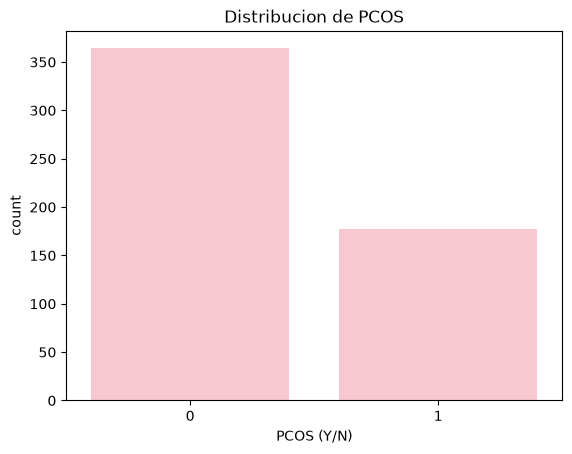

In [18]:
print(df["PCOS (Y/N)"].value_counts())

sns.countplot(data=df, x="PCOS (Y/N)", color="pink")
plt.title("Distribucion de PCOS")
plt.show()

### Observaciones de la variable objetivo

| Clase | Pacientes | Porcentaje |
|---|---|---|
| 0 = Sin PCOS | 364 | 67.3% |
| 1 = Con PCOS | 177 | 32.7% |
| **Total** | **541** | **100%** |

El dataset presenta un **desbalance leve**: la clase con PCOS representa el 32.7% de los registros, lo que equivale a aproximadamente dos pacientes sin PCOS por cada paciente con PCOS. Segun la clasificacion comunmente usada (clase minoritaria entre 20% y 40%), no es un desbalance severo, pero si se toma en cuenta en las siguientes etapas.

---

## 3. Limpieza de datos

Se corrigen los problemas detectados en la seccion 2.2.

---

### 3.1 Eliminar columnas

Se eliminan las columnas que no aportan informacion al analisis: la columna vacia y las columnas de identificacion y signos vitales.

#### Drop de `Unnamed: 42`

Se elimina la columna `Unnamed: 42` detectada en la sección 2.2, ya que esta practicamente vacia.

In [19]:
df = df.drop(columns=["Unnamed: 42"], errors="ignore")

print("Columnas restantes:", df.shape[1])

Columnas restantes: 42


#### Columnas no necesarias para analisis

En el dataset hay columnas no necesarias que podriamos eliminar para no meter "ruido" en nuestro analisis y mucho menos para cuando estemos en la etapa de entrenar un modelo para prediccion o cual sea el caso.

Por lo tanto las columnas que eliminaremos seran `Sl. No`, `Patient File No.`, `Pulse rate(bpm)`, `RR (breaths/min)`, `Marraige Status (Yrs)`, `BP _Systolic (mmHg)` y `BP _Diastolic (mmHg)`.

In [20]:
df = df.drop(columns=["Sl. No", "Patient File No.", "Pulse rate(bpm)", "RR (breaths/min)", "Marraige Status (Yrs)", "BP _Systolic (mmHg)", "BP _Diastolic (mmHg)"])

In [21]:
df.head()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),...,Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,10.48,2,5,0,...,0,0,0,1.0,0,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,11.70,2,5,1,...,0,0,0,0.0,0,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,11.80,2,5,1,...,0,1,1,1.0,0,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.674945,13,12.00,2,5,0,...,0,0,0,0.0,0,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.060954,11,10.00,2,5,1,...,0,1,0,0.0,0,3,4,16.0,14.0,7.0


---

### 3.2 Tipos y valores invalidos

Se corrigen las columnas con tipo de dato incorrecto (`AMH(ng/mL)`) y con valores fuera de las categorias validas (`Cycle(R/I)`), detectadas en la sección 2.2.

#### Limpieza de valores str a numericos

Tomaremos el valor de texto en `AMH(ng/mL)` y haremos imputacion con mediana.

In [22]:
print("Tipo antes:", df["AMH(ng/mL)"].dtype) #imprime el tipo de dato
print("Valor antes en la fila 305:", df.loc[305, "AMH(ng/mL)"]) #la fila fue identificada en el apartado 2.2 Revision de `AMH(ng/mL)`

df["AMH(ng/mL)"] = pd.to_numeric(df["AMH(ng/mL)"], errors="coerce") #.to_numeric -> valores a numeros y coerce -> NaN
print("Nulos después de convertir:", df["AMH(ng/mL)"].isna().sum())

mediana_amh = df["AMH(ng/mL)"].median()
df["AMH(ng/mL)"] = df["AMH(ng/mL)"].fillna(mediana_amh)

print("Mediana usada:", mediana_amh)
print("Tipo después:", df["AMH(ng/mL)"].dtype)
print("Nulos después de imputar:", df["AMH(ng/mL)"].isna().sum())
print("Valor después en la fila 305:", df.loc[305, "AMH(ng/mL)"])

Tipo antes: str
Valor antes en la fila 305: a
Nulos después de convertir: 1
Mediana usada: 3.7
Tipo después: float64
Nulos después de imputar: 0
Valor después en la fila 305: 3.7


#### Datos invalidos en `Cycle(R/I)`

Se reemplaza el 5 por 4 (irregular): es el valor valido mas cercano y la paciente tiene PCOS, donde el ciclo irregular es un sintoma tipico.

In [23]:
print("Antes:\n", df["Cycle(R/I)"].value_counts())
df["Cycle(R/I)"] = df["Cycle(R/I)"].replace(5, 4)
print("Despues:\n", df["Cycle(R/I)"].value_counts())

Antes:
 Cycle(R/I)
2    390
4    150
5      1
Name: count, dtype: int64
Despues:
 Cycle(R/I)
2    390
4    151
Name: count, dtype: int64


---

### 3.3 Estandarizacion a sistema metrico

Se convierten las medidas de cintura y cadera de pulgadas a centimetros para trabajar todo en sistema metrico.

In [24]:
if "Waist(inch)" in df.columns and "Hip(inch)" in df.columns:
    # Convertir a cm
    df["Waist(cm)"] = (df["Waist(inch)"] * 2.54).round(2)
    df["Hip(cm)"] = (df["Hip(inch)"] * 2.54).round(2)
    
    
    df.drop(columns=["Waist(inch)", "Hip(inch)"], inplace=True)
    print(" Transformacion a cm realizada exitosamente.")

elif "Waist(cm)" in df.columns and "Hip(cm)" in df.columns:
    print(" Las columnas ya fueron transformadas a 'Waist(cm)' y 'Hip(cm)'.")
else:
    print(" Revisa el nombre exacto de tus columnas con `print(df.columns)`.")

 Transformacion a cm realizada exitosamente.


In [25]:
# Verificar que Waist:Hip ratio se mantiene con las medidas en cm
waist_hip_calculado = (df["Waist(cm)"] / df["Hip(cm)"]).round(2)
correcto = np.isclose(df["Waist:Hip Ratio"], waist_hip_calculado, atol=0.01)

print("Registros correctos:", correcto.sum())
print("Registros incorrectos:", (~correcto).sum())

Registros correctos: 541
Registros incorrectos: 0


---

### 3.4 Outliers

Se grafican boxplots de las variables numéricas continuas (se excluyen las binarias y las categóricas) para identificar valores atípicos. Después se distingue entre valores imposibles (errores de captura) y valores extremos pero fisiológicamente posibles; solo los primeros se corrigen.

In [26]:
binarias = [c for c in df.columns if "(Y/N)" in c]
excluir_binarias = binarias + ["Blood Group", "Cycle(R/I)"]
numericas = [c for c in df.select_dtypes("number").columns if c not in excluir_binarias]

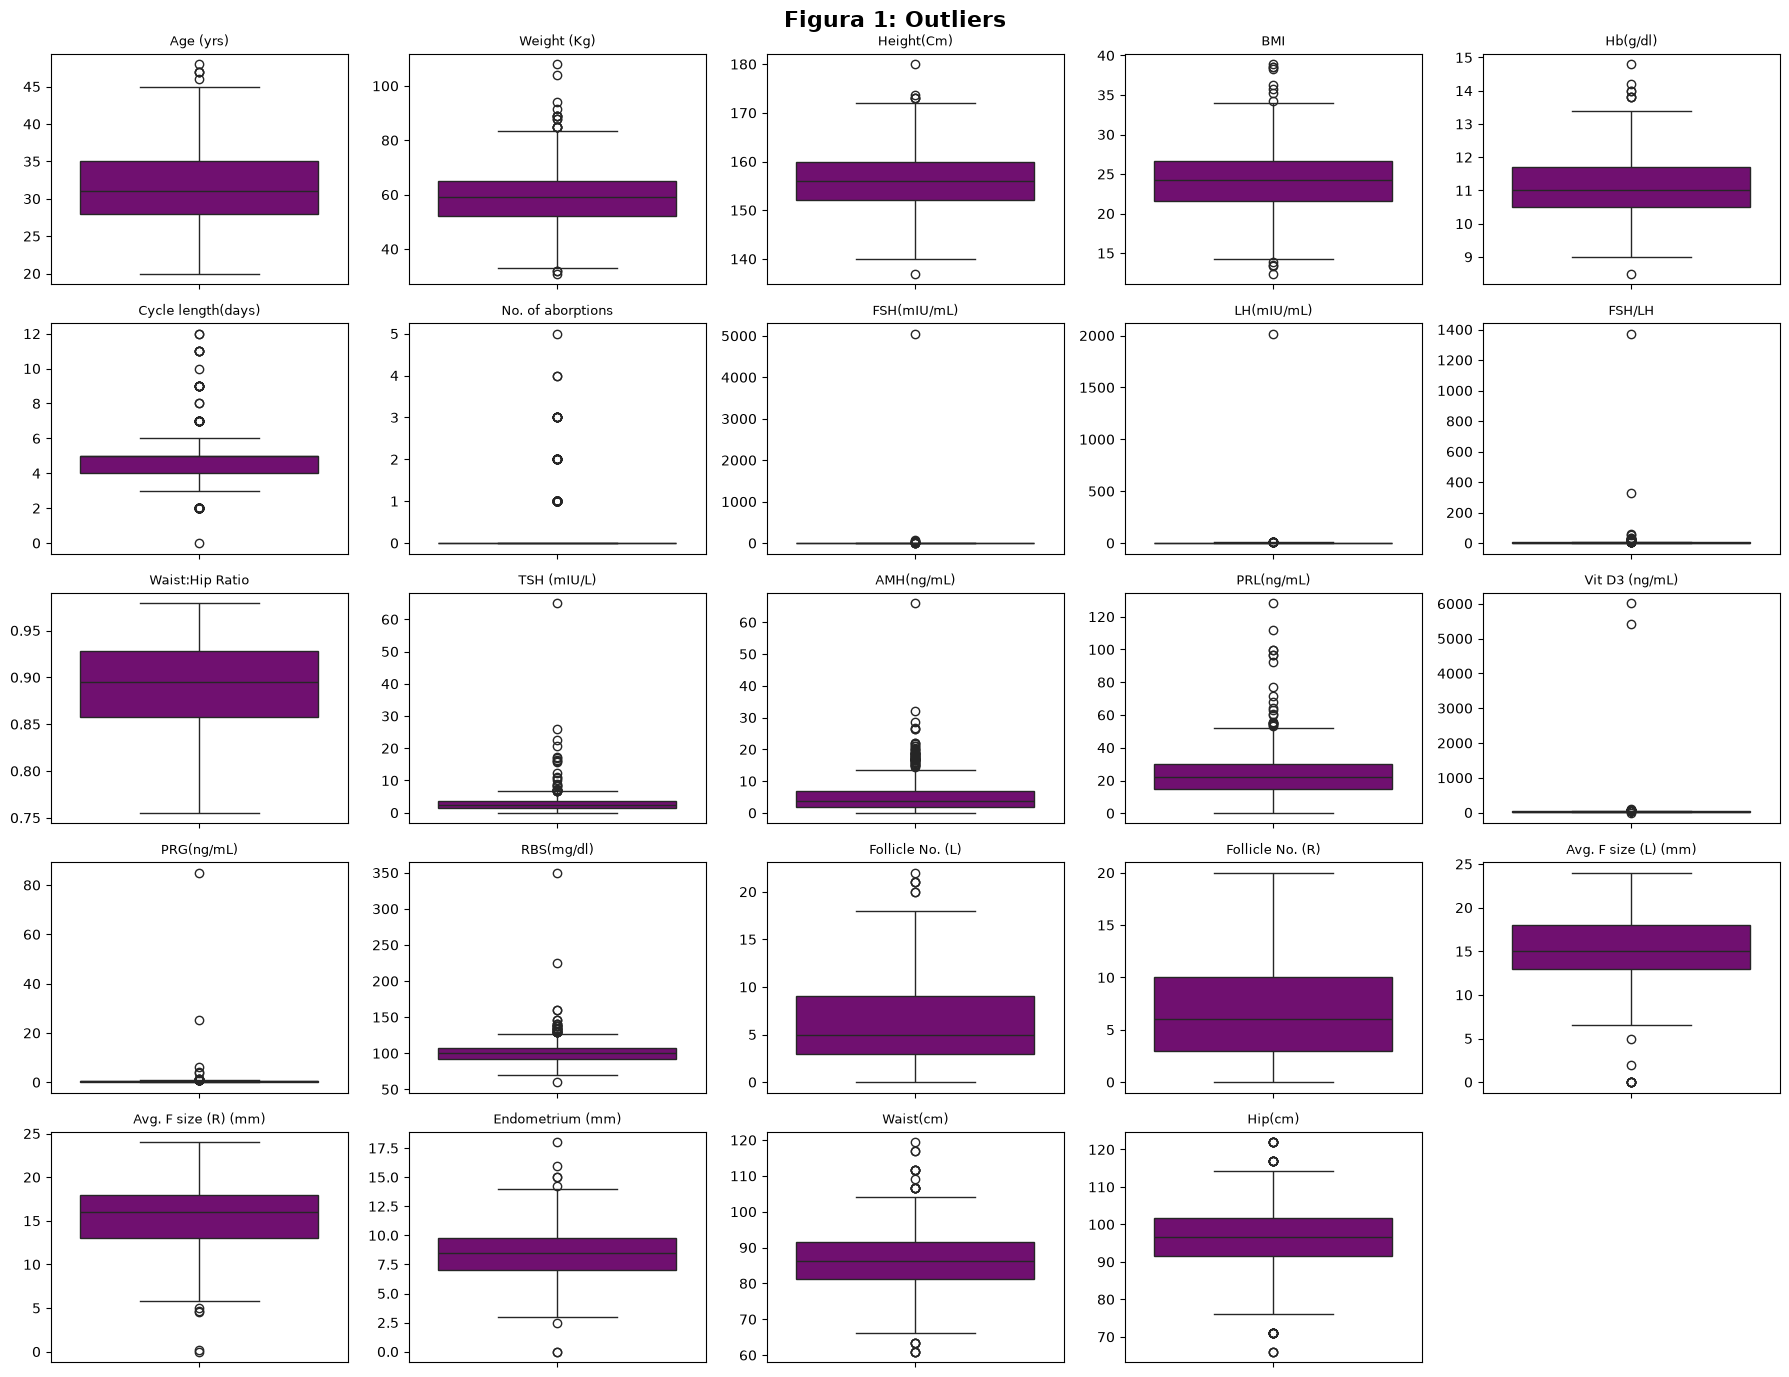

In [27]:
fig, axes = plt.subplots(5, 5, figsize=(18, 14))
for ax, col in zip(axes.flat, numericas):
    sns.boxplot(y=df[col], ax=ax, color="purple")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes.flat[len(numericas):]:
    ax.set_visible(False)

fig.suptitle("Figura 1: Outliers", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 1 - Outliers.png", dpi=150, bbox_inches="tight")
plt.show()

### Notas sobre el grafico

Se pueden observar dentro de la **Figura 1: Outliers**, las graficas para `FSH(mIU/mL)`, `LH(mIU/mL)` y su variable compuesta `FSH/LH` se ven de esa forma debido a que hay valores fuera de rango posible. Los rangos normales para una mujer dependen de la fase de su ciclo y podrian ser de la siguiente manera:


| Fase | Días | Rango |
|---|---|---|
| Ciclo menstrual (fase basal) | Días 2 a 5 | 3 a 9 mUI/mL |
| Mitad del ciclo (pico ovulatorio) | — | 6 a 17 mUI/mL |
| Mujeres posmenopáusicas | — | Mayor de 20 a 40 mUI/mL |

Para otras etiquetas como BMI se encuentran outliers pero dentro de un rango "normal" para la fisiologia humana. Un BMI de ~40 indica obesidad tipo II.

Fuera de esto los demas valores representan un valor posible fisiologico probablemente no normal pero si presente. Lo que seguira es la correccion de los outliers para las hormonas de interes y de esta forma se podra "arreglar" nuestras graficas.

Para el caso de Vitamina D3, esta es otra hormona que se muestra con valores imposibles. Los valores normales de esta Vitamina D3 en el cuerpo son de:

| Clasificación | Rango (ng/mL) | Observaciones |
|---|---|---|
| Deficiencia severa | < 10–12 | — |
| Deficiencia (carencia) | < 20 | — |
| Insuficiencia | 20 a 29 | Niveles que pueden ser bajos para mantener una buena salud ósea a largo plazo |
| Normal / óptimo | 30 a 100 | Algunos especialistas y guías consideran ideal un rango de 40 a 60 ng/mL |
| Toxicidad (exceso) | > 150 | Suele ocurrir solo por un consumo excesivo y prolongado de suplementos en dosis muy altas |

Con los valores mostrados en la **Figura 1: Outliers** podemos concluir que son imposibles debido a que al tener una concentracion mayor a 150 ng/mL ya estamos hablando de valores toxicos.



### Imputacion con mediana para FSH, LH y Vitamina D3

Con las notas anteriores se decide hacer una imputacion con mediana para los outliers de las hormonas de interes para poder asi recalcular las variables compuestas (solo FSH/LH).

### FSH 

Se usa 1000 como limite porque separa claramente los errores de captura: el siguiente valor mas alto es 65.4 en FSH, 14.69 en LH y 90 en Vit D3.

In [28]:
print("FSH antes:", df["FSH(mIU/mL)"].max())
df.loc[df["FSH(mIU/mL)"] > 1000, "FSH(mIU/mL)"] = np.nan
df["FSH(mIU/mL)"] = df["FSH(mIU/mL)"].fillna(df["FSH(mIU/mL)"].median())
print("FSH después:", df["FSH(mIU/mL)"].max())

FSH antes: 5052.0
FSH después: 65.4


### LH

Se usa 1000 como limite porque separa claramente los errores de captura: el siguiente valor más alto es 65.4 en FSH, 14.69 en LH y 90 en Vit D3.

In [29]:
print("LH antes:", df["LH(mIU/mL)"].max())
df.loc[df["LH(mIU/mL)"] > 1000, "LH(mIU/mL)"] = np.nan
df["LH(mIU/mL)"] = df["LH(mIU/mL)"].fillna(df["LH(mIU/mL)"].median())
print("LH después:", df["LH(mIU/mL)"].max())

LH antes: 2018.0
LH después: 14.69


### Vitamina D3

Se usa 1000 como limite porque separa claramente los errores de captura: el siguiente valor mas alto es 65.4 en FSH, 14.69 en LH y 90 en Vit D3.

In [30]:
print("Vit D3 antes:", df["Vit D3 (ng/mL)"].max())
df.loc[df["Vit D3 (ng/mL)"] > 1000, "Vit D3 (ng/mL)"] = np.nan
df["Vit D3 (ng/mL)"] = df["Vit D3 (ng/mL)"].fillna(df["Vit D3 (ng/mL)"].median())
print("Vit D3 despues:", df["Vit D3 (ng/mL)"].max())

Vit D3 antes: 6014.66
Vit D3 despues: 90.0


---

### 3.5 Recalculo de variables compuestas

Se hace despues de tratar los outliers para que las variables compuestas usen los valores ya corregidos.

In [31]:
df["BMI"] = (df["Weight (Kg)"] / ((df["Height(Cm)"] / 100) ** 2)).round(2)

In [32]:
#Recalcular BMI y comparar contra lo que corregimos
bmi_calculado = (df["Weight (Kg)"] / (df["Height(Cm)"] / 100) ** 2).round(2)
correcto = np.isclose(df["BMI"], bmi_calculado, atol=1e-2)

print("Registros correctos:", correcto.sum())
print("Registros incorrectos:", (~correcto).sum())

Registros correctos: 541
Registros incorrectos: 0


In [33]:
df["FSH/LH"] = (df["LH(mIU/mL)"] / df["FSH(mIU/mL)"]).round(2)

FSHLH_correcto = (df["LH(mIU/mL)"] / df["FSH(mIU/mL)"]).round(2)
correcto = np.isclose(df["FSH/LH"], FSHLH_correcto, atol=0.01)
print("Registros incorrectos despues de corregir:", (~correcto).sum())

Registros incorrectos despues de corregir: 0


### 3.6 Imputacion de faltantes

`Fast food (Y/N)` es binaria y tiene un solo faltante, por lo que se imputa con la moda. Las demas variables con valores corregidos (AMH, FSH, LH y Vit D3) ya fueron imputadas en las secciones 3.2 y 3.4.

In [34]:
print("Nulos antes:", df["Fast food (Y/N)"].isna().sum())
df["Fast food (Y/N)"] = df["Fast food (Y/N)"].fillna(df["Fast food (Y/N)"].mode()[0]).astype(int)
print("Nulos despues:", df["Fast food (Y/N)"].isna().sum())

Nulos antes: 1
Nulos despues: 0


### Resultado de la limpieza

Se revisa la estructura final del dataset despues de todas las correcciones: numero de columnas, tipos de dato y ausencia de valores nulos.

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PCOS (Y/N)            541 non-null    int64  
 1   Age (yrs)             541 non-null    int64  
 2   Weight (Kg)           541 non-null    float64
 3   Height(Cm)            541 non-null    float64
 4   BMI                   541 non-null    float64
 5   Blood Group           541 non-null    int64  
 6   Hb(g/dl)              541 non-null    float64
 7   Cycle(R/I)            541 non-null    int64  
 8   Cycle length(days)    541 non-null    int64  
 9   Pregnant(Y/N)         541 non-null    int64  
 10  No. of aborptions     541 non-null    int64  
 11  FSH(mIU/mL)           541 non-null    float64
 12  LH(mIU/mL)            541 non-null    float64
 13  FSH/LH                541 non-null    float64
 14  Waist:Hip Ratio       541 non-null    float64
 15  TSH (mIU/L)           541 non-null

### Conclusion de limpieza de datos

Se corrigieron todos los problemas detectados en la seccion 2.2. El dataset paso de **541 filas x 43 columnas** a **541 filas x 35 columnas**, sin eliminar ningun registro (paciente) y sin valores nulos.

| Problema | Accion | Registros afectados |
|---|---|---|
| `Unnamed: 42` vacia (539 de 541 nulos) | Eliminada | Columna completa |
| Columnas de identificacion, signos vitales y `Marraige Status (Yrs)` | Eliminadas por no aportar al analisis | 7 columnas |
| `AMH(ng/mL)` como texto (valor `"a"`) | Conversion a numerico e imputacion con mediana (3.7) | 1 |
| `Cycle(R/I)` con valor invalido (5) | Reemplazado por 4 (irregular) | 1 |
| `Waist(inch)` y `Hip(inch)` en pulgadas | Convertidas a cm; `Waist:Hip Ratio` se mantiene correcto | Todas |
| Valores imposibles en `FSH(mIU/mL)`, `LH(mIU/mL)` y `Vit D3 (ng/mL)` (> 1000) | Imputacion con mediana | 1, 1 y 2 |
| `BMI` inconsistente con peso / altura^2 | Recalculado para todo el dataset | 6 |
| `FSH/LH` inconsistente | Recalculado con FSH y LH ya corregidos | 1 (+ los afectados por outliers) |
| `Fast food (Y/N)` con 1 faltante | Imputacion con moda y conversion a entero | 1 |

Ninguna paciente fue eliminada. Con 541 registros y una clase minoritaria de 177 pacientes, borrar filas habria significado perder informacion y aumentar el desbalance, por lo que se prefirio imputar. Para las variables continuas se uso la mediana, ya que a diferencia de la media no se ve arrastrada por los valores extremos que todavia existen en las hormonas, y para la unica variable binaria con faltante se uso la moda.

Tambien se distinguio entre dos tipos de valores atipicos. Solo se corrigieron los fisiologicamente imposibles (por ejemplo, una Vit D3 de 6014 ng/mL); los valores extremos pero posibles, como un BMI cercano a 39, se conservaron porque pueden ser informativos. Las variables compuestas se recalcularon al final, una vez corregidos sus componentes, para que fueran consistentes con los datos limpios. El resultado es un dataset de 35 columnas, todas numericas y sin valores nulos, listo para el analisis exploratorio.

---

## 4. EDA sobre datos limpios

Una vez corregidos los problemas detectados en la seccion 2, se realiza un analisis exploratorio sobre el dataset limpio (541 pacientes y 35 columnas). A diferencia de la seccion 2, cuyo objetivo era encontrar errores, aqui el objetivo es **entender el comportamiento de las variables y su relacion con el diagnostico de PCOS**.

Este analisis sirve como base para las siguientes etapas: ayuda a identificar que variables podrian ser mas utiles para distinguir entre pacientes con y sin PCOS, cuales son redundantes entre si y si es necesario transformar alguna variable antes de entrenar un modelo.

La seccion se divide en cuatro partes:

| Apartado | Que se hara | Por que |
|---|---|---|
| **4.1 Analisis univariado** | Graficar la distribucion de cada variable por separado: histogramas y boxplots para las variables continuas y graficos de barras para las binarias y categoricas. | Para conocer la forma de cada distribucion (simetrica, sesgada, con valores extremos) y detectar variables que podrian necesitar una transformacion o escalamiento. |
| **4.2 Analisis bivariado (vs PCOS)** | Comparar cada variable entre pacientes con y sin PCOS mediante boxplots por clase y proporciones de sintomas por grupo. | Para identificar que variables muestran diferencias claras entre ambos grupos y, por lo tanto, podrian ser buenas predictoras del diagnostico. |
| **4.3 Correlaciones** | Calcular la matriz de correlacion y visualizarla con un mapa de calor. | Para medir que tan relacionada esta cada variable con `PCOS (Y/N)` y detectar variables muy correlacionadas entre si (por ejemplo `Weight`, `BMI` y `Waist`), que aportan informacion redundante. |
| **4.4 Conclusiones del EDA** | Resumir los hallazgos principales de los apartados anteriores. | Para justificar las decisiones de las secciones de extraccion, seleccion de caracteristicas y reduccion de dimensionalidad. |

### 4.1 Analisis Univariado

Se analiza la distribucion de cada variable por separado, sin relacionarla todavia con el diagnostico de PCOS. Las variables se dividen en tres grupos segun su tipo:

- **Continuas y de conteo** (24 variables): se grafican con histogramas y curva de densidad (KDE) para observar la forma de su distribucion, y se calcula el coeficiente de asimetria (*skewness*).
- **Binarias** (Y/N): se grafica la proporcion de pacientes que presentan cada sintoma o habito.
- **Categoricas** (`Blood Group` y `Cycle(R/I)`): se grafican con conteos por categoria.

El coeficiente de asimetria indica que tan sesgada esta una distribucion: valores cercanos a 0 indican una distribucion simetrica, valores mayores a 1 (o menores a -1) indican un sesgo fuerte hacia la derecha (o izquierda).

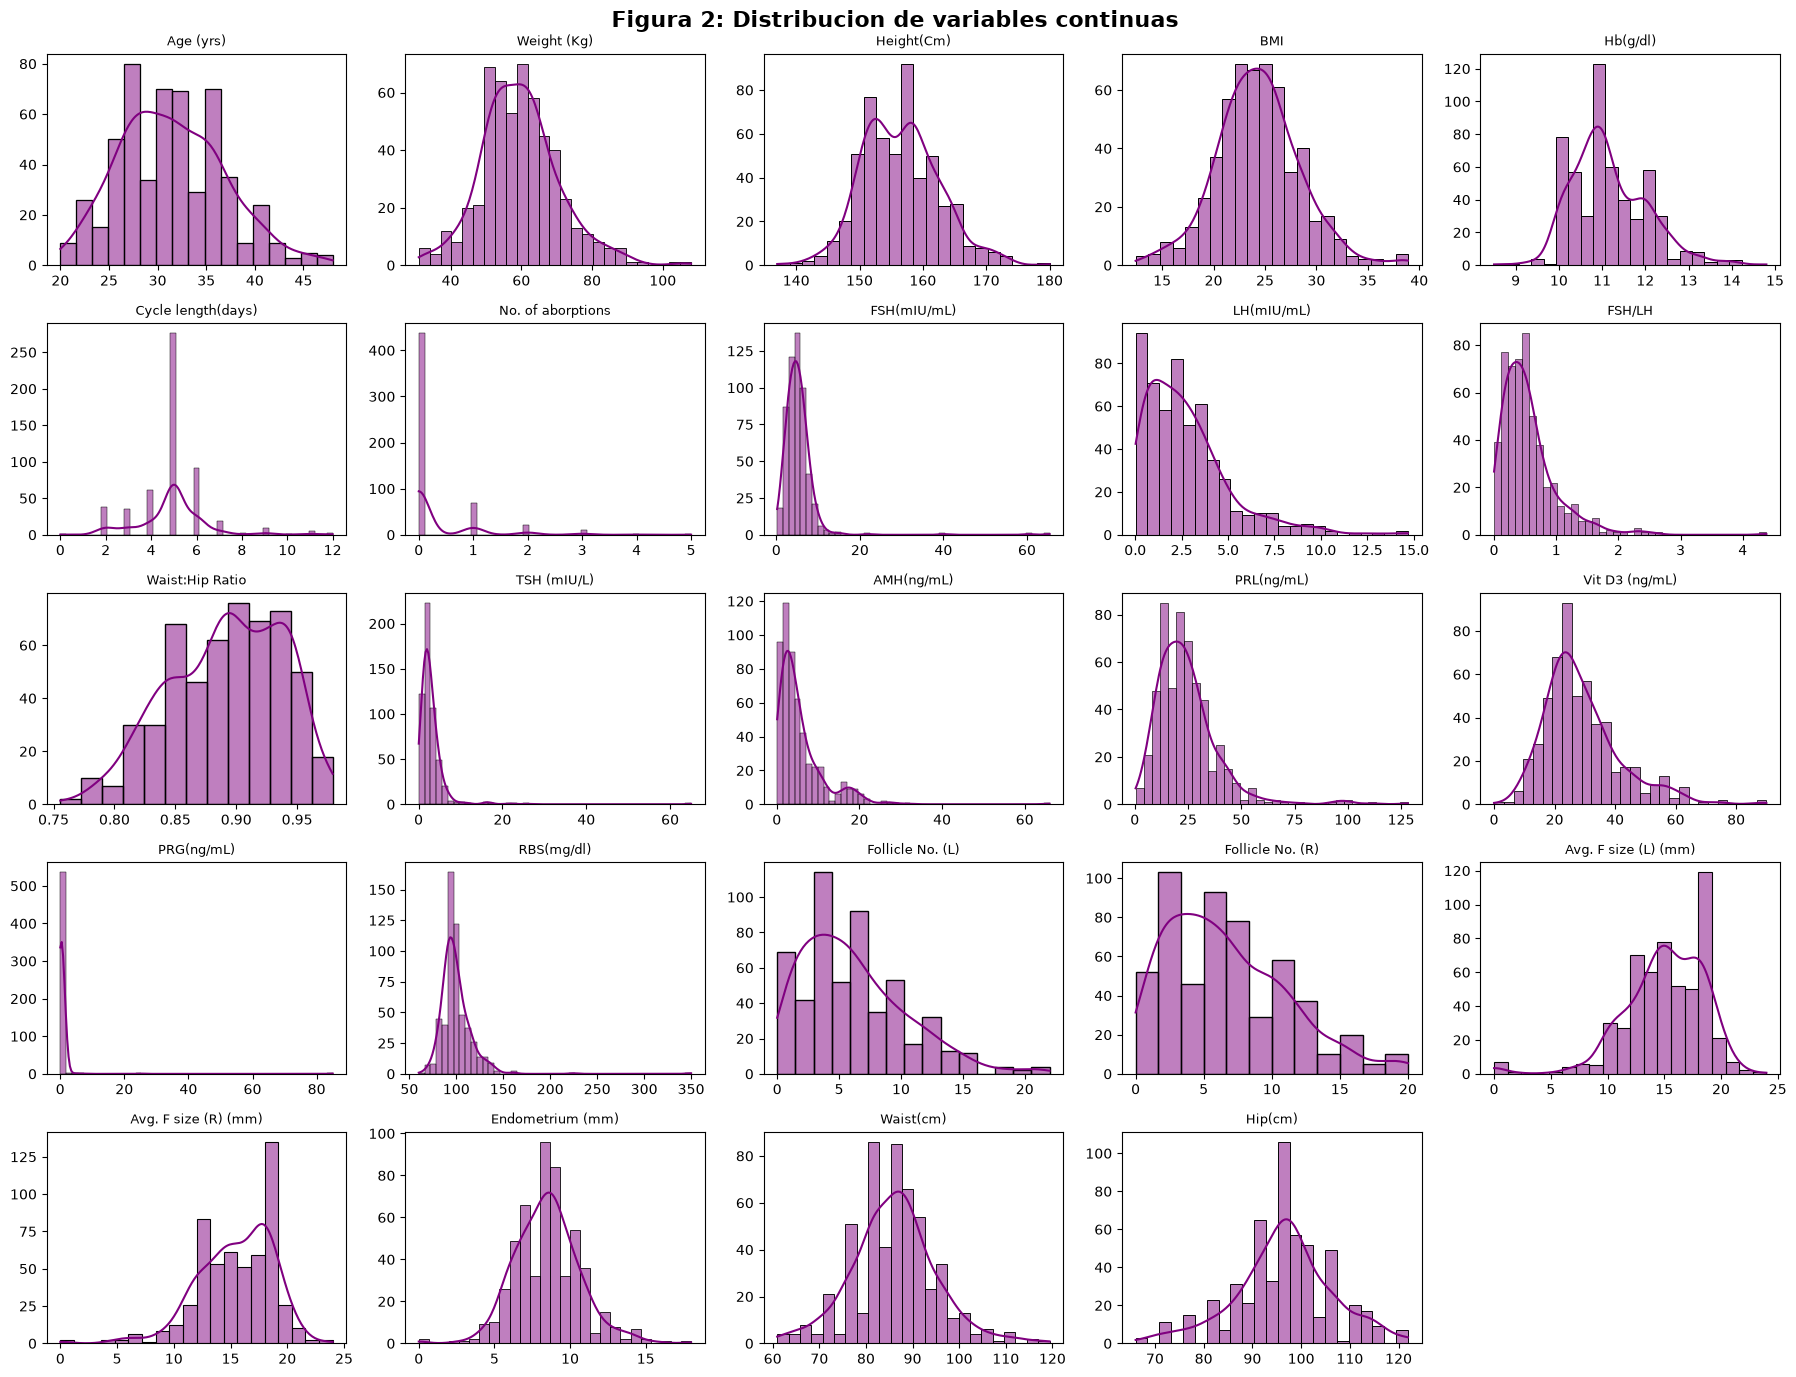

In [36]:
binarias = [c for c in df.columns if "(Y/N)" in c]
categoricas = ["Blood Group", "Cycle(R/I)"]
numericas = [c for c in df.select_dtypes("number").columns if c not in binarias + categoricas]

fig, axes = plt.subplots(5, 5, figsize=(18,14))
for ax, col in zip(axes.flat, numericas):
    sns.histplot(x=df[col], kde=True, ax=ax, color="purple")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.flat[len(numericas):]:
    ax.set_visible(False)

fig.suptitle(
    "Figura 2: Distribucion de variables continuas",
    fontsize=16,
    fontweight="bold"
    )
plt.tight_layout()
plt.savefig("Images/Figura 2 - Distribucion de variables continuas.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
asimetria = df[numericas].agg(["mean","median","min","max","skew"]).T.round(2)
asimetria.sort_values("skew", ascending=False)


,mean,median,min,max,skew
PRG(ng/mL),0.61,0.32,0.05,85.00,20.73
TSH (mIU/L),2.98,2.26,0.04,65.00,9.79
FSH(mIU/mL),5.27,4.84,0.21,65.40,8.94
RBS(mg/dl),99.84,100.00,60.00,350.00,5.49
AMH(ng/mL),5.62,3.70,0.10,66.00,3.30
No. of aborptions,0.29,0.00,0.00,5.00,2.97
FSH/LH,0.55,0.46,0.00,4.38,2.47
PRL(ng/mL),24.32,21.92,0.40,128.24,2.44
LH(mIU/mL),2.74,2.28,0.02,14.69,1.66
Vit D3 (ng/mL),28.88,25.90,0.00,90.00,1.23


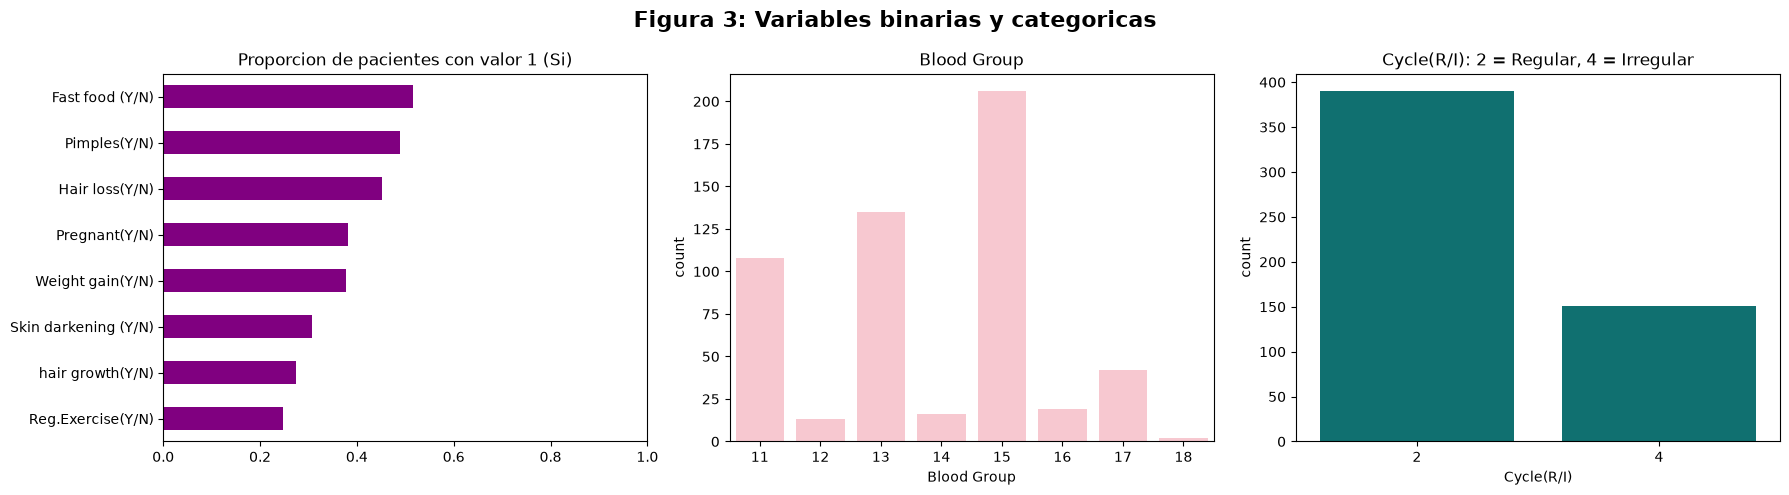

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

proporciones = df[[c for c in binarias if c != "PCOS (Y/N)"]].mean().sort_values()
proporciones.plot(kind="barh", ax=axes[0], color="purple")
axes[0].set_title("Proporcion de pacientes con valor 1 (Si)")
axes[0].set_xlim(0, 1)

sns.countplot(data=df, x="Blood Group", ax=axes[1], color="pink")
axes[1].set_title("Blood Group")

sns.countplot(data=df, x="Cycle(R/I)", ax=axes[2], color="teal")
axes[2].set_title("Cycle(R/I): 2 = Regular, 4 = Irregular")

fig.suptitle("Figura 3: Variables binarias y categoricas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 3 - Variables binarias y categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

#### Clasificacion de grupos sanguineos

Dentro del dataset no se muestra la clave explicitamente para cada grupo sanguineo, esto se aclara justo en Kaggle por el mismo autor, la clasificacion de grupos queda asi:

| Codigo | Grupo sanguineo |
|---|---|
| 11 | A+ |
| 12 | A- |
| 13 | B+ |
| 14 | B- |
| 15 | O+ |
| 16 | O- |
| 17 | AB+ |
| 18 | AB- |

### Observaciones del analisis univariado

**Variables con distribucion aproximadamente simetrica** (asimetria entre -0.5 y 0.5): `Age (yrs)`, `Height(Cm)`, `BMI`, `Waist(cm)`, `Hip(cm)`, `Waist:Hip Ratio` y `Endometrium (mm)`. Sus medias y medianas son practicamente iguales. Por ejemplo, el BMI tiene media de 24.3 y mediana de 24.2, lo que indica que la mayoria de las pacientes estan en el rango de peso normal a sobrepeso.

**Variables con sesgo moderado a la derecha** (asimetria entre 0.5 y 1.5): `Weight (Kg)`, `Hb(g/dl)`, `Cycle length(days)`, `Follicle No. (L)`, `Follicle No. (R)` y `Vit D3 (ng/mL)`. La mayoria de los valores se concentran en la parte baja con algunas pacientes con valores altos.

**Variables con sesgo fuerte a la derecha** (asimetria mayor a 1.5): `LH`, `PRL`, `No. of aborptions`, `AMH`, `RBS`, `FSH`, `TSH`, `FSH/LH` y `PRG`. Principalmente son hormonas y valores de laboratorio, donde la mayoria de las pacientes tienen niveles bajos y unas pocas tienen niveles muy altos. Destacan:
- `FSH/LH (o LH/FSH)`: Tras la limpieza de valores atípicos y ceros en el denominador, la variable muestra una distribución suave sesgada a la derecha con un rango acotado entre 0 y 4 (concentrada en su mayoría entre 0.2 y 1.5).
- `PRG(ng/mL)` (asimetria de 20.7) con mediana de 0.32 y maximo de 85.
- `TSH (mIU/L)` con mediana de 2.26 y maximo de 65.
- `AMH(ng/mL)` con media de 5.62 y mediana de 3.70. Es una hormona relevante para PCOS, por lo que sus valores altos podrian estar asociados al diagnostico.

**Variables con sesgo a la izquierda**: `Avg. F size (L) (mm)` y `Avg. F size (R) (mm)`, debido a algunos registros con valor 0 (7 y 1 respectivamente), que podrian representar ausencia de foliculos medibles o datos no registrados. Tambien hay valores 0 en `Follicle No. (L)` (10), `Follicle No. (R)` (11) y `Endometrium (mm)` (2).

**Variables binarias**: los sintomas mas frecuentes son `Pimples` (49%) y `Hair loss` (45%), mientras que `hair growth` (27%) es el menos comun. Un 52% de las pacientes reporta consumo de comida rapida y solo un 25% hace ejercicio regularmente.

**Variables categoricas**:
- `Cycle(R/I)`: el 72% de las pacientes tiene ciclo regular y el 28% irregular.
- `Blood Group`: el grupo mas comun es el 15 (O+) con 206 pacientes, seguido de 13 (B+) y 11 (A+). Los grupos negativos son poco frecuentes. Al ser una variable codificada con numeros, debe tratarse como categorica y no como numerica en el modelo.



---

### 4.2 Analisis bivariado (vs PCOS)

Se compara cada variable entre las pacientes **sin PCOS (0)** y **con PCOS (1)** para identificar cuales muestran diferencias entre ambos grupos y, por lo tanto, podrian ayudar a predecir el diagnostico.

- **Variables continuas:** se comparan con boxplots por grupo. Como muchas variables tienen distribuciones sesgadas (seccion 4.1), se usa la prueba de **Mann-Whitney U**, que compara las distribuciones de ambos grupos sin suponer normalidad.
- **Variables binarias y categoricas:** se compara el porcentaje de pacientes con cada sintoma en ambos grupos y se usa la prueba de **Chi-cuadrada** para saber si existe asociacion con el diagnostico.

En ambas pruebas, un **p-valor menor a 0.05** indica que la diferencia entre grupos es estadisticamente significativa.

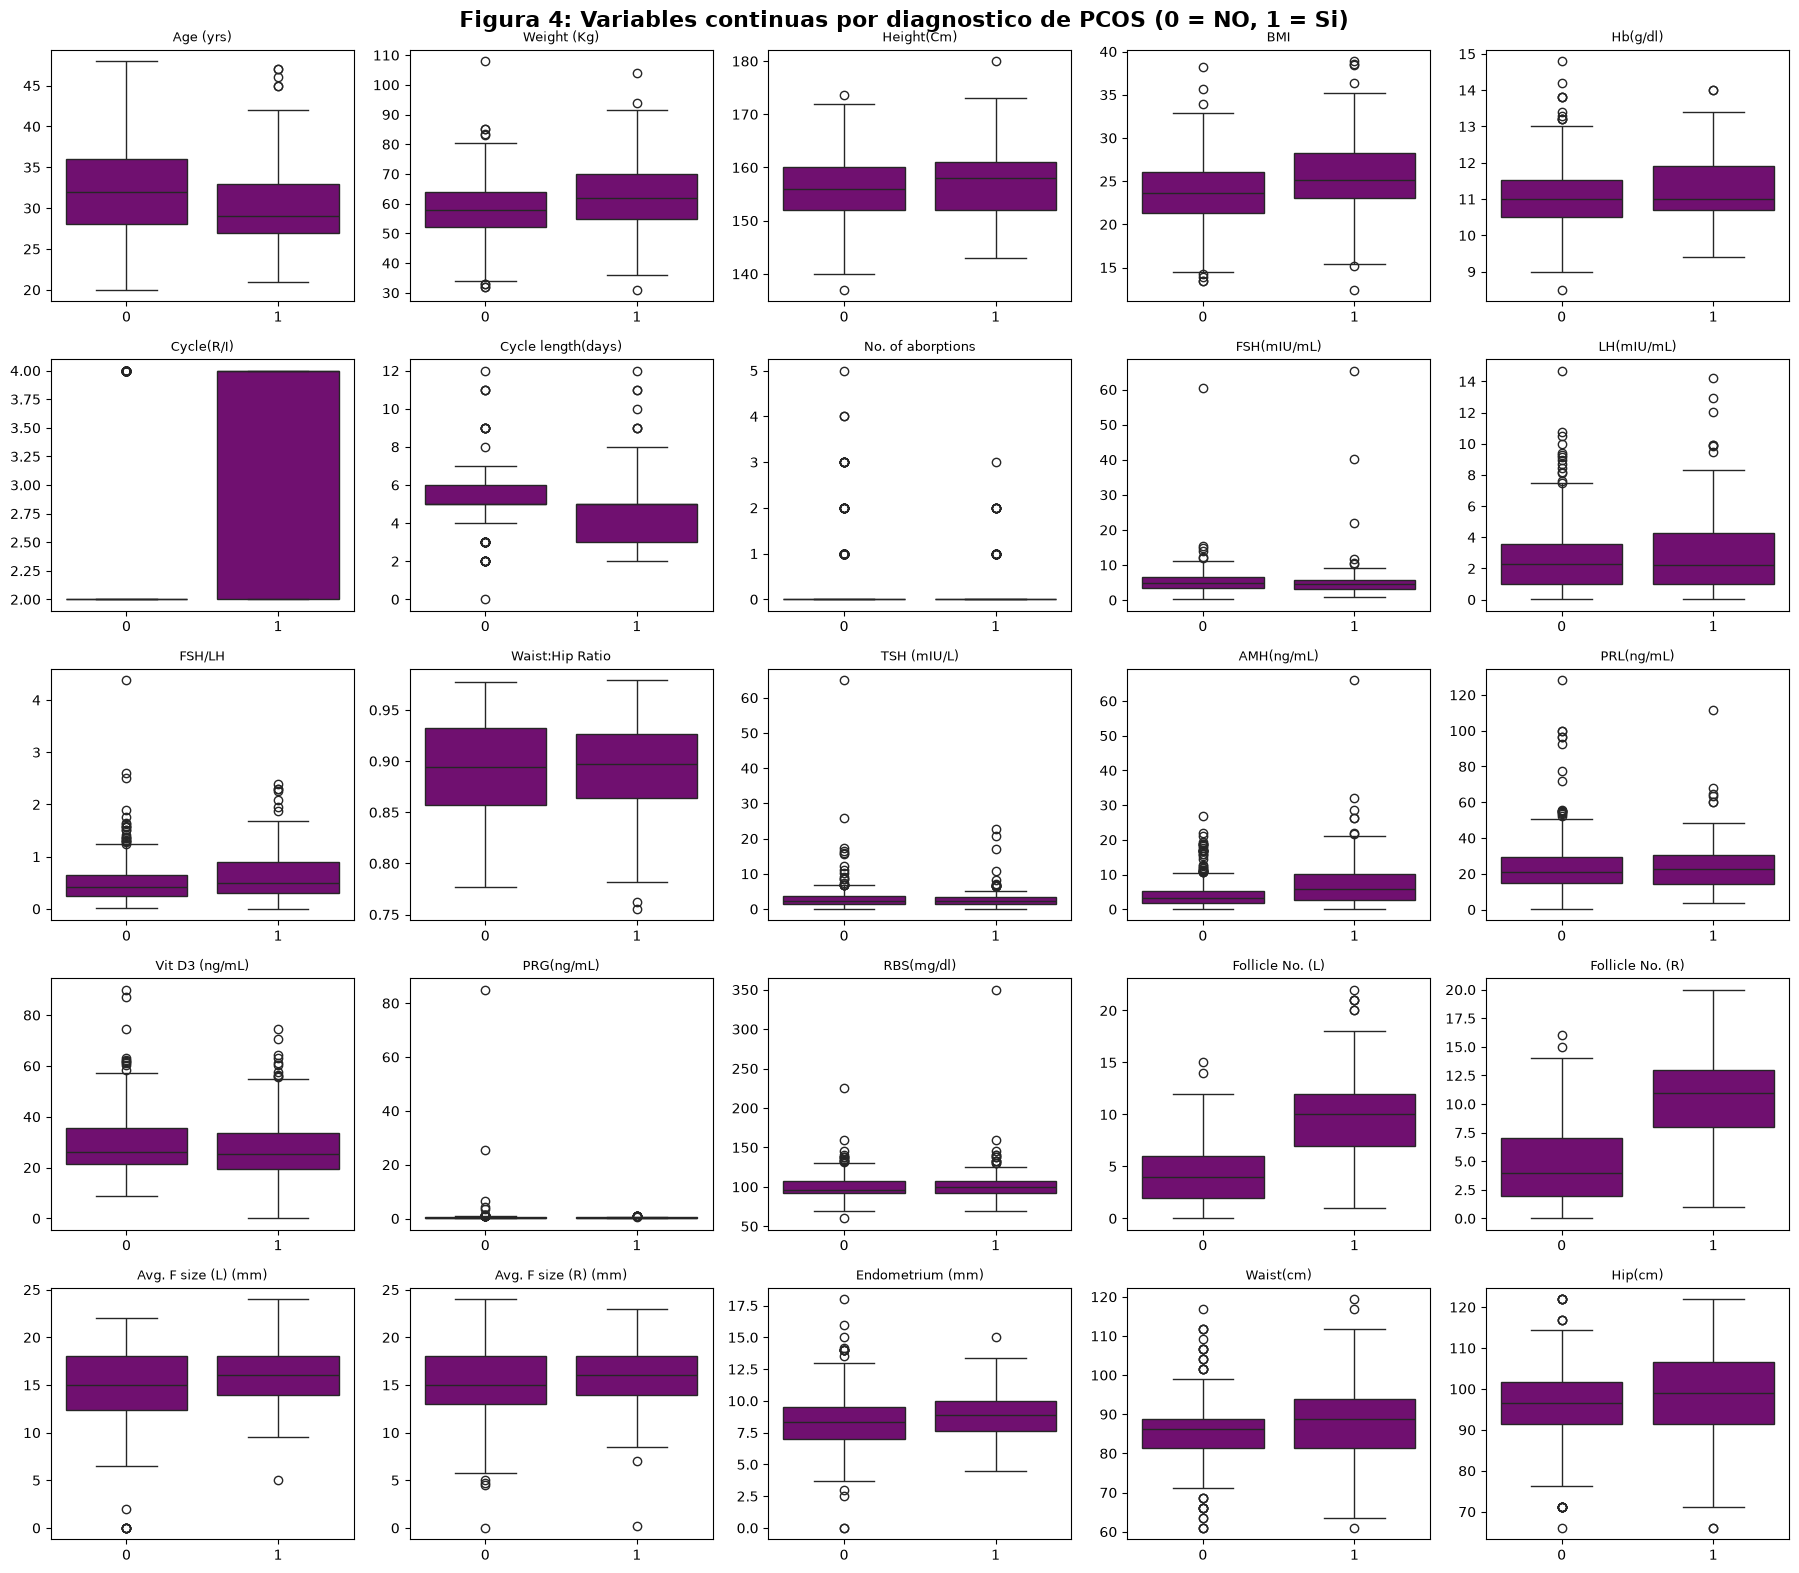

In [39]:
objetivo = "PCOS (Y/N)"
binarias = [c for c in df.columns if "(Y/N)" in c and c!=objetivo]
categoricas = ["Blood Group", "Cycle (R/I)"]
numericas = [c for c in df.select_dtypes("number").columns if c not in binarias + categoricas + [objetivo]]

fig, axes = plt.subplots(5, 5, figsize=(18, 16))
for ax, col in zip(axes.flat, numericas):
    sns.boxplot(data=df, x=objetivo, y=col, ax=ax, color="purple")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes.flat[len(numericas):]:
    ax.set_visible(False)

fig.suptitle("Figura 4: Variables continuas por diagnostico de PCOS (0 = NO, 1 = Si)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 4 - Variables continuas vs PCOS.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones del analisis bivariado

La diferencia mas contundente entre ambos grupos esta en el **numero de foliculos**. Las pacientes con PCOS tienen una mediana de 10 a 11 foliculos por ovario, frente a 4 en el grupo sin PCOS, lo que coincide directamente con el criterio ecografico de Rotterdam. Algo similar ocurre con el ciclo menstrual: el 54% de las pacientes con PCOS tiene ciclo irregular, contra solo el 15% del grupo sin PCOS. La AMH tambien es claramente mas alta en el grupo con PCOS (mediana de 5.90 vs 3.21 ng/mL), lo cual es esperable porque esta hormona refleja la cantidad de foliculos en desarrollo.

Los sintomas clinicos muestran diferencias igual de marcadas. El aumento de peso, el crecimiento de vello, el oscurecimiento de la piel y el acne son entre dos y cuatro veces mas frecuentes en las pacientes con PCOS, y todos resultaron significativos en la prueba de Chi-cuadrada. El consumo de comida rapida tambien aparece asociado (79% vs 39%), aunque esta relacion podria estar mediada por el peso.

Las variables antropometricas muestran diferencias mas moderadas:

- `Weight` y `BMI` son mayores en el grupo con PCOS; la mediana del BMI pasa de 23.6 a 25.2, justo en el limite del sobrepeso.
- `Waist` y `Hip` aumentan ligeramente, en coherencia con el peso.
- La edad es algo menor en las pacientes con PCOS (29 vs 32 años).

En cuanto a las gonadotropinas, la LH por si sola no muestra diferencias significativas entre grupos (p = 0.41), pero la FSH es ligeramente menor en las pacientes con PCOS. Como consecuencia, el cociente LH/FSH aumenta ligeramente en este grupo (0.43 vs 0.49), aunque con un amplio solapamiento.

El resto de las variables aporta poco para distinguir entre grupos. `PRL`, `TSH`, `PRG`, `RBS`, `Vit D3`, `Height` y `Waist:Hip Ratio` no presentan diferencias significativas. `Endometrium`, `Hb` y el tamaño promedio de los foliculos si resultan significativos en Mann-Whitney, pero sus diferencias son muy pequeñas (por ejemplo, 8.3 vs 8.9 mm en endometrio). Esto sugiere que lo distintivo del PCOS no es el tamaño de los foliculos sino su numero.

---

### 4.3 Correlaciones

Se calcula la matriz de correlacion entre todas las variables para responder dos preguntas:

1. **¿Que variables estan mas relacionadas con `PCOS (Y/N)`?** Ayuda a identificar candidatas para la seleccion de caracteristicas.
2. **¿Que variables estan muy relacionadas entre si?** Variables con correlacion alta aportan informacion redundante y pueden afectar a algunos modelos (multicolinealidad).

Se usa la **correlacion de Spearman** en lugar de Pearson porque varias variables tienen distribuciones sesgadas y valores extremos (seccion 4.1). Spearman trabaja con rangos, por lo que es mas robusta ante outliers y detecta relaciones monotonicas aunque no sean lineales.

Se excluye `Blood Group`, ya que es una variable categorica nominal y sus codigos numericos no tienen un orden

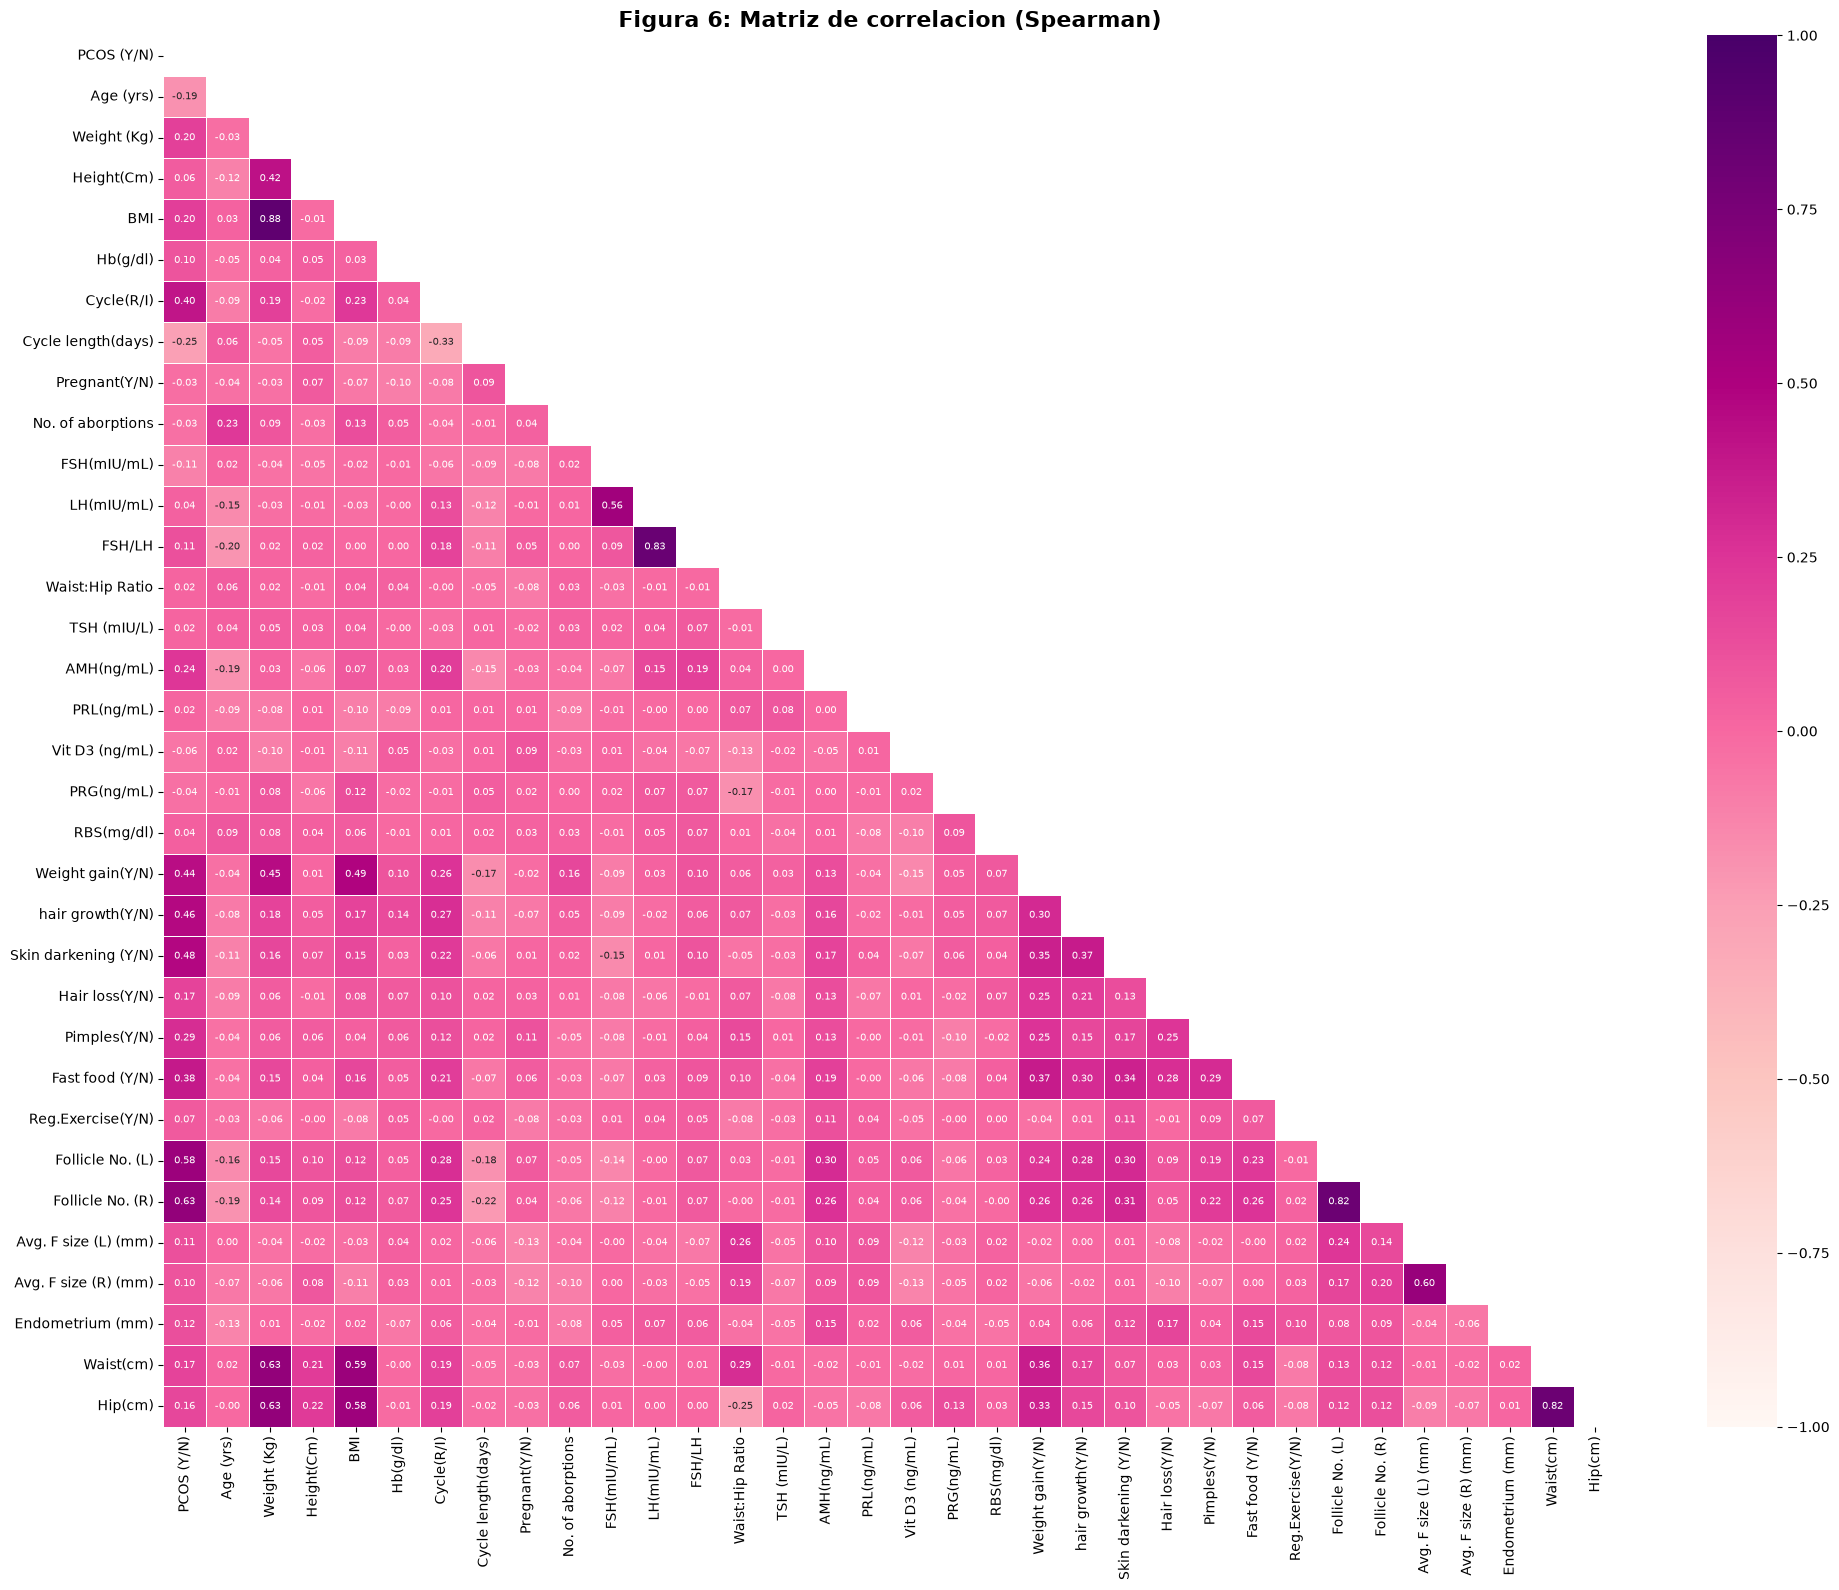

In [40]:
corr = df.drop(columns=["Blood Group"]).corr(method="spearman")
mascara = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20,16))
sns.heatmap(
    corr, 
    mask=mascara, 
    cmap="RdPu", 
    center=0, 
    vmin=-1, 
    vmax=1, 
    annot=True, 
    fmt=".2f", 
    annot_kws={"size": 7},
    linewidths=0.5
)

plt.title("Figura 6: Matriz de correlacion (Spearman)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 6 - Matriz de correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones de la matriz de correlacion (Spearman)

#### Criterios diagnosticos (correlacion esperada)

Las variables que forman parte de los criterios de Rotterdam muestran las correlaciones mas altas con `PCOS (Y/N)`: `Follicle No. (R)` ($r = 0.63$) y `Follicle No. (L)` ($r = 0.58$) como criterio ecografico, `Cycle(R/I)` ($r = 0.40$) como criterio de disfuncion ovulatoria y `hair growth` ($r = 0.46$) como manifestacion de hiperandrogenismo clinico. Este comportamiento es esperado, ya que el diagnostico se basa en el cumplimiento de al menos dos de estos criterios, y confirma la coherencia interna del dataset.

#### Manifestaciones metabolicas y dermatologicas (alto valor practico)

Sintomas que no forman parte de los criterios diagnosticos, como `Skin darkening` ($r = 0.48$) y `Weight gain` ($r = 0.44$), presentan correlaciones moderadas con el diagnostico. Ambos se asocian con la resistencia a la insulina, frecuente en pacientes con PCOS. Su importancia radica en que son señales de alerta visibles y accesibles sin necesidad de pruebas de laboratorio o ecografias.

---

### 4.3 Correlaciones

Se calcula la correlacion entre variables para responder dos preguntas:

1. **¿Que variables estan mas relacionadas con `PCOS (Y/N)`?** Ayuda a identificar candidatas para la seleccion de caracteristicas.
2. **¿Que variables estan muy relacionadas entre si?** Variables con correlacion alta aportan informacion redundante (multicolinealidad).

Se usa la **correlacion de Spearman** en lugar de Pearson porque varias variables tienen distribuciones sesgadas y valores extremos (seccion 4.1). Spearman trabaja con rangos, por lo que es mas robusta ante outliers.

Como una matriz con todas las variables es dificil de leer, el analisis se divide en dos partes:
- **Correlacion con la variable objetivo:** grafico de barras con todas las variables ordenadas segun su correlacion con `PCOS (Y/N)`.
- **Sub-matrices por bloques tematicos:** se agrupan las variables segun su naturaleza (hormonal, antropometrica y clinica/ecografica) para analizar las relaciones dentro de cada grupo. Se incluye `PCOS (Y/N)` en cada bloque como referencia.

Se excluye `Blood Group`, ya que es una variable categorica nominal y sus codigos no tienen un orden.

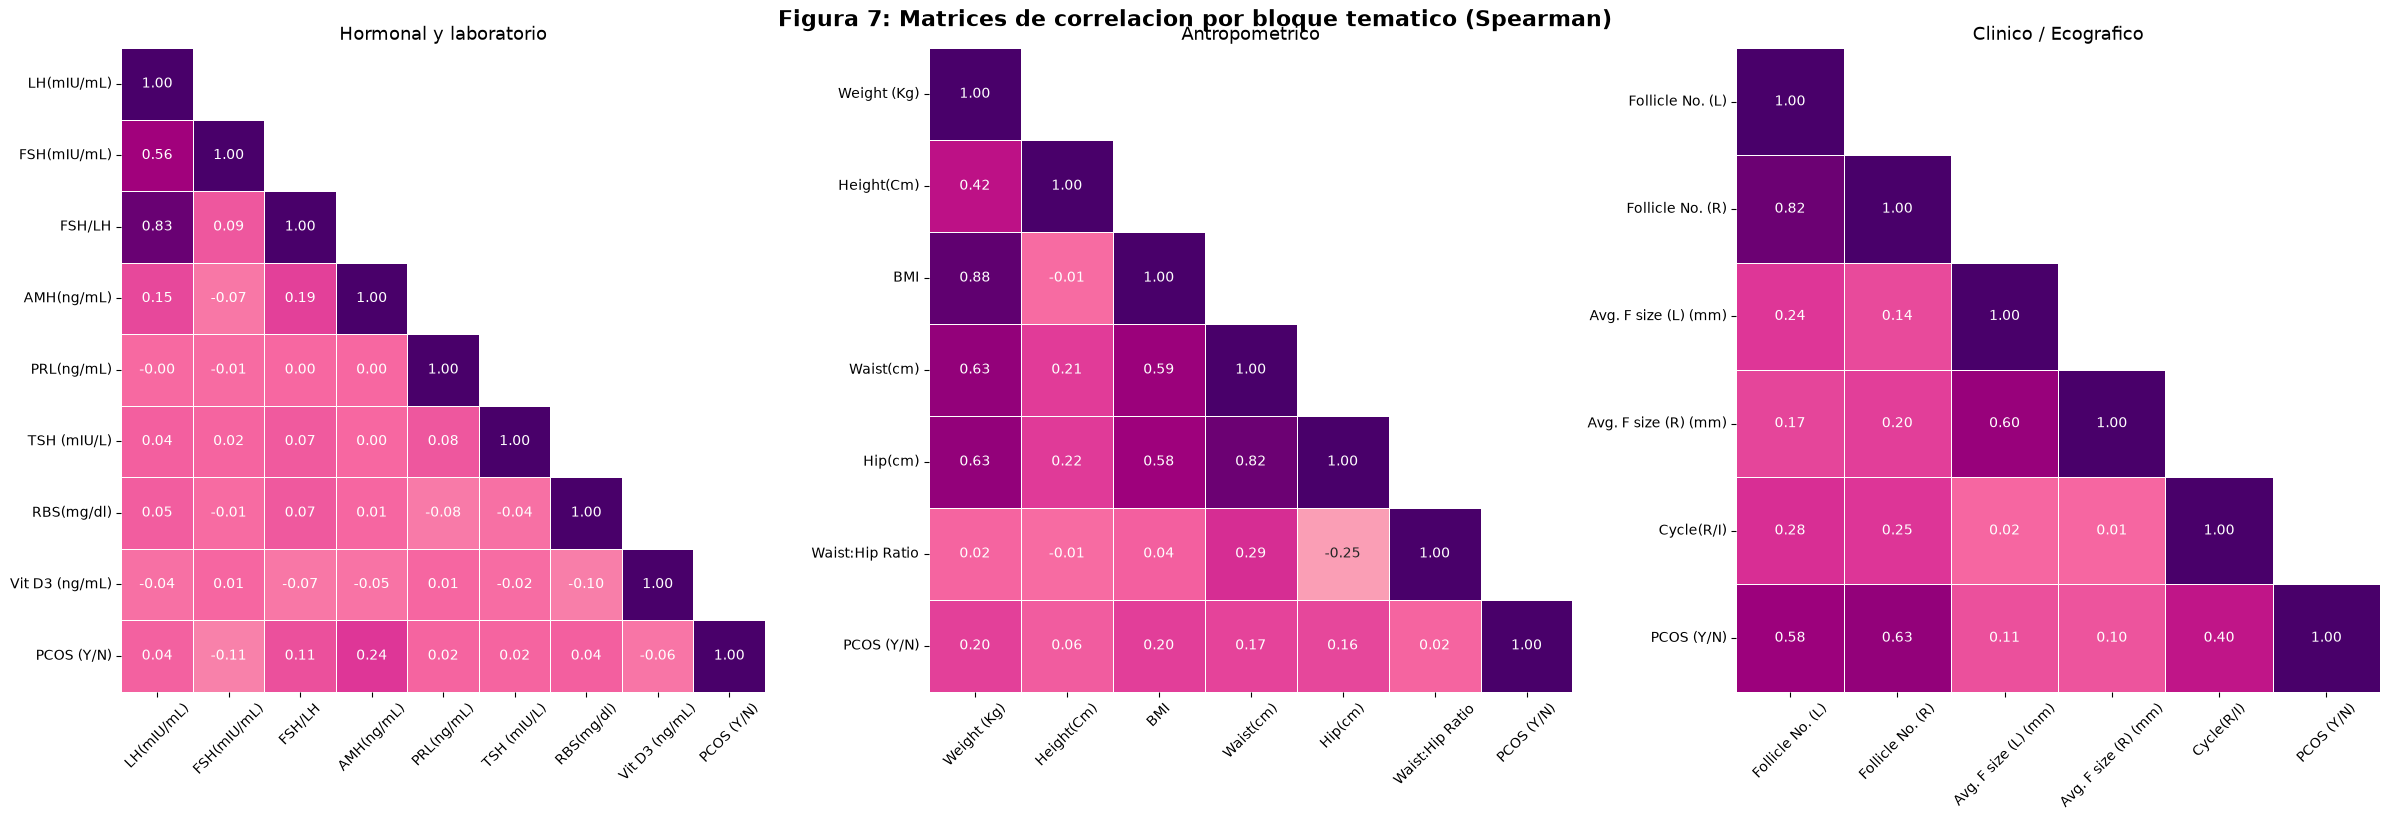

In [41]:
cociente = "LH/FSH" if "LH/FSH" in df.columns else "FSH/LH"

bloques = {
    "Hormonal y laboratorio": ["LH(mIU/mL)", "FSH(mIU/mL)", cociente, "AMH(ng/mL)", "PRL(ng/mL)",
                               "TSH (mIU/L)", "RBS(mg/dl)", "Vit D3 (ng/mL)"],
    "Antropometrico": ["Weight (Kg)", "Height(Cm)", "BMI", "Waist(cm)", "Hip(cm)", "Waist:Hip Ratio"],
    "Clinico / Ecografico": ["Follicle No. (L)", "Follicle No. (R)", "Avg. F size (L) (mm)",
                             "Avg. F size (R) (mm)", "Cycle(R/I)"],
}

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (nombre, columnas) in zip(axes, bloques.items()):
    corr_bloque = df[columnas + ["PCOS (Y/N)"]].corr(method="spearman")
    mascara = np.triu(np.ones_like(corr_bloque, dtype=bool), k=1)
    sns.heatmap(
        corr_bloque, 
        mask=mascara, 
        cmap="RdPu", 
        center=0, 
        vmin=-1, 
        vmax=1,
        annot=True, 
        fmt=".2f", 
        square=True, 
        linewidths=0.5, 
        cbar=False, 
        ax=ax
    )
    ax.set_title(nombre, fontsize=13)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Figura 7: Matrices de correlacion por bloque tematico (Spearman)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 7 - Correlacion por bloques.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones de las correlaciones

Las variables con mayor correlacion con el diagnostico son, en su mayoria, las que forman parte de los criterios de Rotterdam. El numero de foliculos tiene la relacion mas fuerte (`Follicle No. (R)` $r = 0.63$ y `Follicle No. (L)` $r = 0.58$), seguido del crecimiento de vello ($r = 0.46$), que es una manifestacion de hiperandrogenismo clinico, y de la irregularidad del ciclo ($r = 0.40$). Que estas variables encabecen el ranking es esperado, ya que el diagnostico se construye a partir de ellas, y confirma la coherencia interna del dataset.

Fuera de los criterios diagnosticos destacan el oscurecimiento de la piel ($r = 0.48$) y el aumento de peso ($r = 0.44$), ambos asociados con la resistencia a la insulina. Su valor practico es que son señales visibles que no requieren estudios de laboratorio ni ultrasonido.

Al analizar cada bloque por separado se observa lo siguiente:

- **Hormonal:** la AMH es la unica hormona con una relacion apreciable ($r = 0.24$). La FSH muestra una relacion inversa debil ($r = -0.11$) y el cociente LH/FSH una positiva igual de debil ($r = 0.11$), mientras que PRL, TSH, RBS y Vit D3 son practicamente neutras ($|r| \le 0.06$).
- **Antropometrico:** todas las variables tienen una relacion debil con PCOS ($r \le 0.20$) y son muy redundantes entre si (`Weight` y `BMI` $r = 0.88$, `Waist` y `Hip` $r = 0.82$). Llama la atencion que `Waist:Hip Ratio` no aporte ninguna señal ($r = 0.02$).
- **Clinico/ecografico:** ademas de la fuerte relacion de los foliculos con el diagnostico, existe una alta redundancia entre ambos ovarios ($r = 0.82$). El tamaño promedio de los foliculos casi no se relaciona con PCOS ($r \approx 0.10$).

En conjunto, el diagnostico se relaciona mucho mas con hallazgos ecograficos y clinicos que con el perfil hormonal, algo que se explora en la seccion 5.

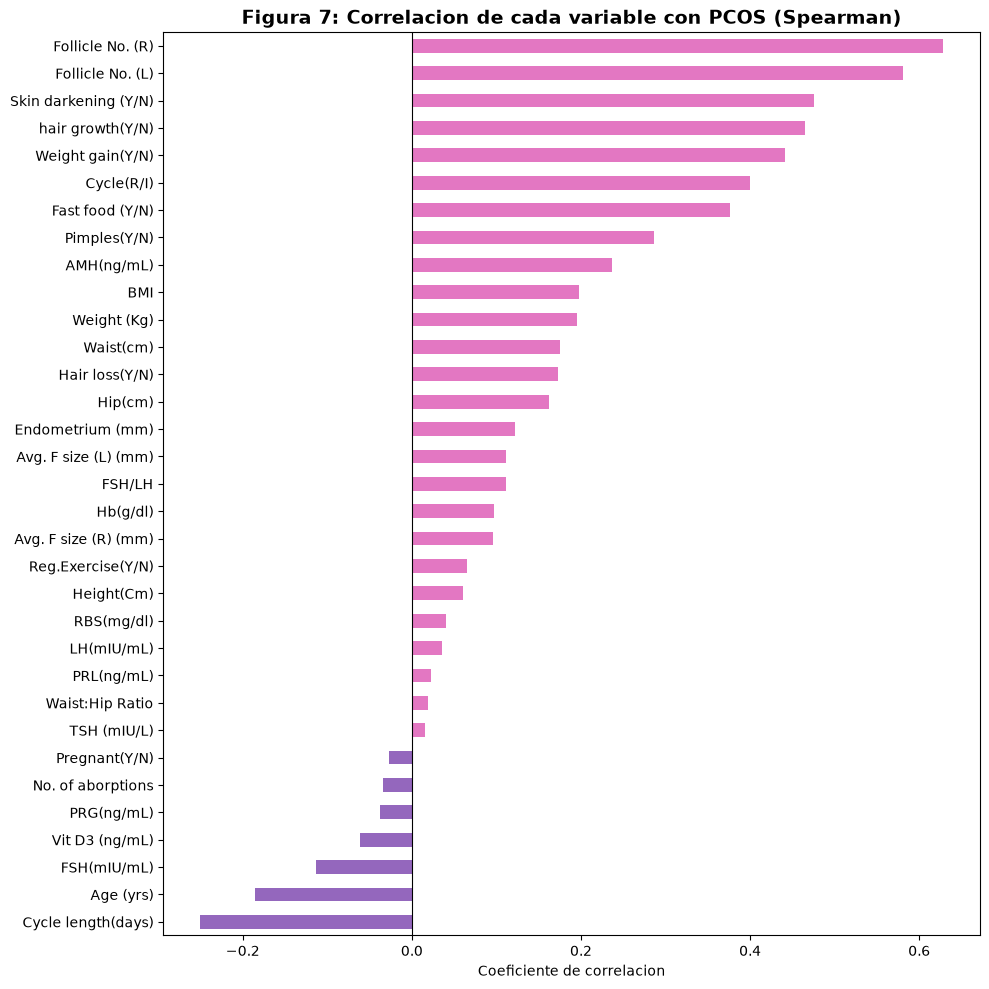

In [42]:
corr_pcos = corr["PCOS (Y/N)"].drop("PCOS (Y/N)").sort_values()

plt.figure(figsize=(10, 10))
colores = ["tab:purple" if v < 0 else "tab:pink" for v in corr_pcos]
corr_pcos.plot(kind="barh", color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Figura 7: Correlacion de cada variable con PCOS (Spearman)", fontsize=14, fontweight="bold")
plt.xlabel("Coeficiente de correlacion")
plt.tight_layout()
plt.savefig("Images/Figura 7 - Correlacion con PCOS.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 5. Reduccion de dimensionalidad

Se aplican dos tecnicas de reduccion de dimensionalidad sobre el **perfil hormonal** de las pacientes, para observar si las hormonas por si solas permiten distinguir grupos entre pacientes con y sin PCOS:

| Tecnica | Tipo | Que conserva |
|---|---|---|
| **PCA** (Analisis de Componentes Principales) | Lineal | La **varianza global**: busca las direcciones donde los datos varian mas |
| **t-SNE** (t-distributed Stochastic Neighbor Embedding) | No lineal | La **estructura local**: pacientes con perfiles parecidos quedan cerca |

Ambas son **no supervisadas**: no usan `PCOS (Y/N)` para calcular la proyeccion, solo para colorear los puntos.

**Variables utilizadas:** `FSH`, `LH`, `AMH`, `PRL`, `TSH`, `PRG` y `Vit D3`.

- Se excluyen las variables binarias, antropometricas y ecograficas para centrar el analisis en el componente hormonal.
- Se excluye el cociente `LH/FSH`, ya que se calcula a partir de LH y FSH y no aporta informacion nueva (correlacion de 0.83 con LH).

**Preprocesamiento:**

1. **Transformacion logaritmica** (`log1p`): las hormonas tienen distribuciones muy sesgadas (seccion 4.1). Sin esta transformacion, PCA y t-SNE quedarian dominados por las pocas pacientes con valores extremos. Se usa `log1p` (logaritmo de 1 + x) porque algunas variables tienen valores de 0.
2. **Estandarizacion** con `StandardScaler`: las hormonas tienen escalas muy distintas (por ejemplo, PRL hasta 128 y LH hasta 14.7), y ambas tecnicas se basan en varianzas y distancias.

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

hormonas = ["FSH(mIU/mL)", "LH(mIU/mL)", "AMH(ng/mL)", "PRL(ng/mL)",
            "TSH (mIU/L)", "PRG(ng/mL)", "Vit D3 (ng/mL)"]

y = df["PCOS (Y/N)"]
X = np.log1p(df[hormonas])
X_escalado = StandardScaler().fit_transform(X)

print("Asimetria antes del log:\n", df[hormonas].skew().round(2))
print("\nAsimetria despues del log:\n", pd.DataFrame(np.log1p(df[hormonas])).skew().round(2))

Asimetria antes del log:
 FSH(mIU/mL)        8.94
LH(mIU/mL)         1.66
AMH(ng/mL)         3.30
PRL(ng/mL)         2.44
TSH (mIU/L)        9.79
PRG(ng/mL)        20.73
Vit D3 (ng/mL)     1.23
dtype: float64

Asimetria despues del log:
 FSH(mIU/mL)       0.57
LH(mIU/mL)        0.11
AMH(ng/mL)        0.34
PRL(ng/mL)       -0.44
TSH (mIU/L)       1.12
PRG(ng/mL)        9.63
Vit D3 (ng/mL)   -0.90
dtype: float64


### 5.1 PCA

Primero se calcula PCA con todas las componentes para ver cuanta varianza explica cada una y cuantas se necesitan para conservar la mayor parte de la informacion.

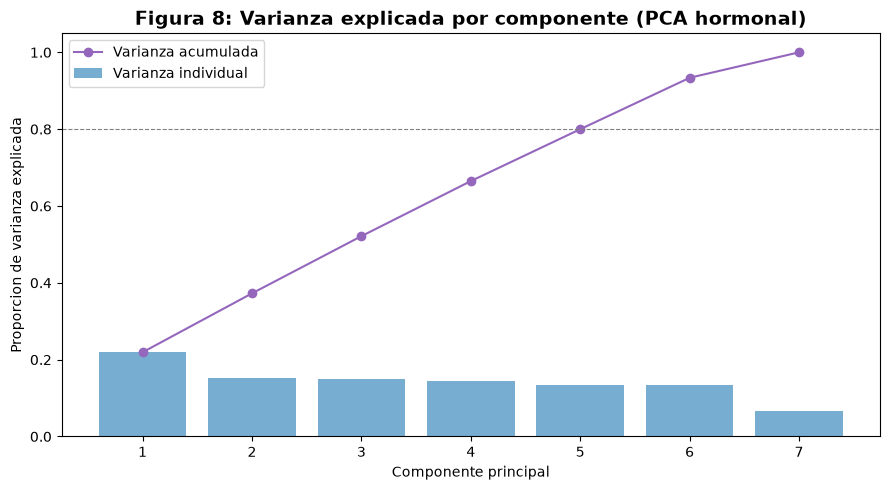

,Varianza,Acumulada
PC1,0.219,0.219
PC2,0.153,0.373
PC3,0.149,0.521
PC4,0.143,0.665
PC5,0.135,0.800
PC6,0.134,0.934
PC7,0.066,1.000


In [44]:
pca = PCA()
pca.fit(X_escalado)

varianza = pca.explained_variance_ratio_
varianza_acumulada = varianza.cumsum()
componentes = range(1, len(varianza) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(componentes, varianza, alpha=0.6, label="Varianza individual")
ax.plot(componentes, varianza_acumulada, marker="o", color="tab:purple", label="Varianza acumulada")
ax.axhline(0.80, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(componentes)
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporcion de varianza explicada")
ax.legend()
plt.title("Figura 8: Varianza explicada por componente (PCA hormonal)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 8 - Varianza explicada PCA.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"Varianza": varianza, "Acumulada": varianza_acumulada}, index=[f"PC{i}" for i in componentes]).round(3)

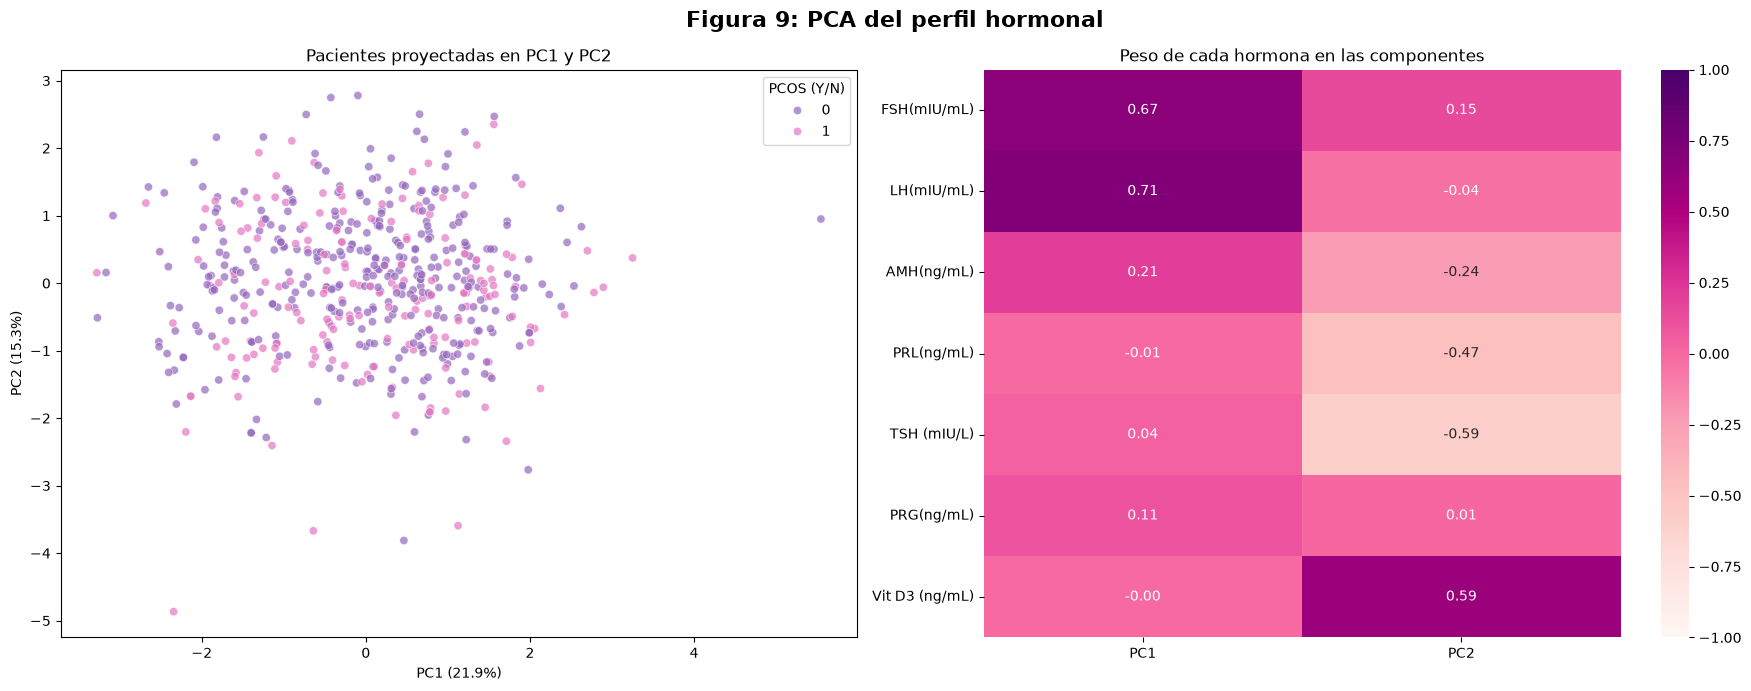

In [45]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_escalado)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette={0: "tab:purple", 1: "tab:pink"}, alpha=0.7, ax=axes[0])
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Pacientes proyectadas en PC1 y PC2")
axes[0].legend(title="PCOS (Y/N)")

cargas = pd.DataFrame(pca_2d.components_.T, index=hormonas, columns=["PC1", "PC2"])
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="RdPu", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Peso de cada hormona en las componentes")

fig.suptitle("Figura 9: PCA del perfil hormonal", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 9 - PCA 2D.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 t-SNE

Se aplica sobre los mismos datos transformados y estandarizados, con `perplexity=30` (numero aproximado de vecinos que considera cada punto) y `random_state=42` para que el resultado sea reproducible. En t-SNE los ejes no tienen interpretacion; solo importa que puntos quedan cerca entre si.

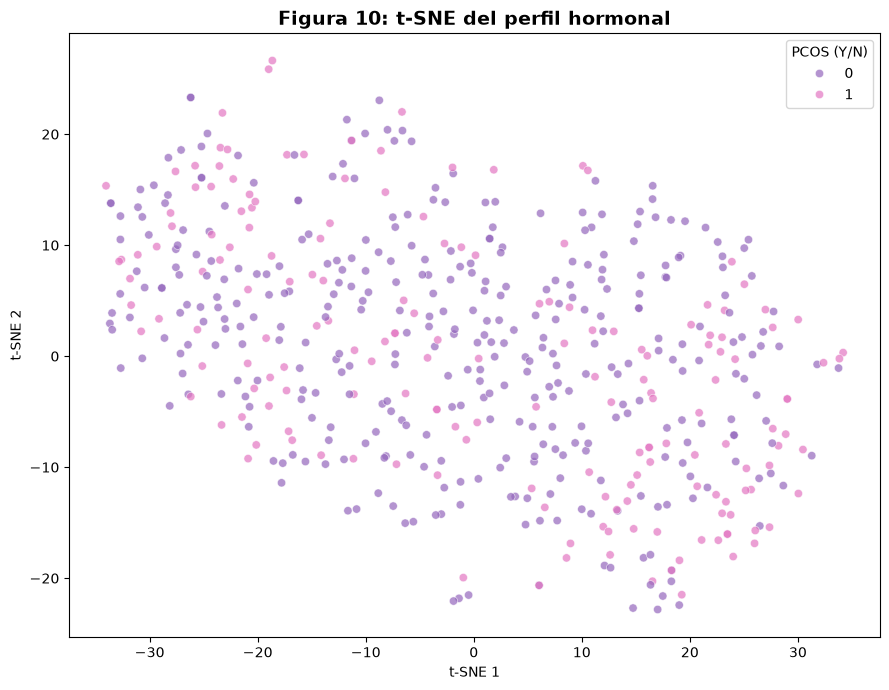

In [46]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_escalado)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette={0: "tab:purple", 1: "tab:pink"}, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="PCOS (Y/N)")
plt.title("Figura 10: t-SNE del perfil hormonal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 10 - t-SNE 2D.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones de la reduccion de dimensionalidad

PCA mostro que la varianza del perfil hormonal esta muy repartida: las dos primeras componentes explican solo el 37.3% (21.9% y 15.3%) y se necesitan 6 de las 7 componentes para llegar al 80%. Esto indica que las hormonas son practicamente independientes entre si y no pueden resumirse en pocas dimensiones. La unica estructura clara es la de PC1, dominada por LH (0.71) y FSH (0.67), que representa el eje de las gonadotropinas. PC2, en cambio, contrapone Vit D3 (0.59) con TSH (-0.59) y PRL (-0.47), hormonas que no pertenecen al eje reproductivo. La AMH, que es la hormona mas relacionada con PCOS, apenas pesa en estas dos componentes.

En la proyeccion de PCA las pacientes con y sin PCOS aparecen completamente mezcladas, y t-SNE, a pesar de capturar relaciones no lineales, llega al mismo resultado. Es decir, pacientes con perfiles hormonales parecidos no necesariamente comparten diagnostico.

Este resultado no es un fallo de las tecnicas, sino un reflejo de los datos. Las hormonas disponibles tienen correlaciones debiles con el diagnostico (seccion 4.3), y los criterios de Rotterdam no se basan en un perfil hormonal especifico sino en hallazgos ecograficos, clinicos y en la medicion de androgenos, que este dataset no incluye. Las implicaciones de este hallazgo se discuten en las conclusiones generales.

---

## 6. Conclusiones

El objetivo de esta practica fue procesar y explorar un dataset clinico de 541 pacientes para entender que variables se relacionan con el diagnostico de sindrome de ovario poliquistico (PCOS). La limpieza corrigio problemas puntuales (valores faltantes, un valor de texto en `AMH`, una categoria invalida en `Cycle(R/I)`, valores hormonales imposibles y variables compuestas mal calculadas) sin eliminar ninguna paciente, lo cual era importante considerando el tamaño del dataset y el desbalance leve entre clases (32.7% con PCOS).

El hallazgo principal es que **el perfil hormonal por si solo no muestra una relacion directa con el diagnostico de PCOS**. Las hormonas disponibles tuvieron correlaciones debiles o practicamente nulas con el diagnostico; la mas alta fue la AMH ($r = 0.24$), mientras que LH, PRL, TSH, PRG y Vit D3 no superaron $|r| = 0.1$. Al aplicar PCA y t-SNE unicamente sobre las hormonas, ninguna de las dos tecnicas mostro una separacion entre pacientes con y sin PCOS: la varianza quedo repartida entre casi todas las componentes (se necesitan 6 de 7 para explicar el 80%) y en ambas proyecciones las dos clases aparecen mezcladas.

Este resultado es coherente con la forma en que se diagnostica el PCOS. Los criterios de Rotterdam establecen que el diagnostico requiere al menos dos de tres caracteristicas: disfuncion ovulatoria, hiperandrogenismo clinico o bioquimico y morfologia de ovario poliquistico en ultrasonido (Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group, 2004). Ninguno de estos criterios corresponde a un valor especifico de FSH, LH, prolactina o TSH; de hecho, estas hormonas se miden principalmente para **descartar otras causas** con sintomas similares, como alteraciones tiroideas o hiperprolactinemia (Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group, 2004; Teede et al., 2023). Por eso no es sorprendente que, en este dataset, las variables mas relacionadas con el diagnostico sean justamente las que corresponden a los criterios:

- el numero de foliculos en ambos ovarios ($r = 0.63$ y $0.58$), que representa el criterio ecografico;
- la irregularidad del ciclo ($r = 0.40$), que representa la disfuncion ovulatoria;
- el crecimiento de vello ($r = 0.46$), que es una manifestacion de hiperandrogenismo clinico.

La AMH es la unica hormona con una relacion apreciable, lo cual tambien tiene sentido: es producida por los foliculos en desarrollo y su concentracion refleja el numero de foliculos (Dewailly et al., 2014). La guia internacional de 2023 incluso la acepta como alternativa al ultrasonido para evaluar la morfologia ovarica en adultas (Teede et al., 2023). Es decir, la AMH se relaciona con PCOS porque funciona como un indicador indirecto del criterio ecografico, no como un marcador hormonal independiente.

El hecho de que PCA y t-SNE no separen las clases tambien se explica por la naturaleza del sindrome. El PCOS es heterogeneo: segun la combinacion de criterios que cumpla cada paciente se distinguen distintos fenotipos (Lizneva et al., 2016), por lo que dos pacientes con el mismo diagnostico pueden tener perfiles muy diferentes. Ademas, PCA solo captura relaciones lineales y busca las direcciones de mayor varianza, que no necesariamente coinciden con las que separan a las clases (Jolliffe & Cadima, 2016). t-SNE, aunque es no lineal, preserva la estructura local de los datos (van der Maaten & Hinton, 2008); si las pacientes con perfiles hormonales parecidos no comparten diagnostico, tampoco formaran grupos en la proyeccion.

Hay que considerar algunas limitaciones. El dataset no incluye testosterona ni otros androgenos, que son los marcadores hormonales directamente ligados al criterio de hiperandrogenismo bioquimico (Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group, 2004; Teede et al., 2023), por lo que el analisis hormonal esta incompleto en ese aspecto. Ademas, como varias de las variables mas relacionadas con el diagnostico forman parte de los propios criterios de Rotterdam, su alta correlacion es en parte esperada, y un modelo predictivo basado en ellas estaria aprendiendo el criterio diagnostico mas que descubriendo una relacion nueva.

En conclusion, el diagnostico de PCOS en este dataset se explica mejor por hallazgos ecograficos y clinicos que por el perfil hormonal, lo cual coincide con los criterios diagnosticos actuales. Un analisis futuro podria incluir androgenos y comparar la reduccion de dimensionalidad sobre los distintos bloques de variables para evaluar que combinacion separa mejor a las pacientes.

### Referencias

Dewailly, D., Andersen, C. Y., Balen, A., Broekmans, F., Dilaver, N., Fanchin, R., Griesinger, G., Kelsey, T. W., La Marca, A., Lambalk, C., Mason, H., Nelson, S. M., Visser, J. A., Wallace, W. H., & Anderson, R. A. (2014). The physiology and clinical utility of anti-Müllerian hormone in women. *Human Reproduction Update, 20*(3), 370–385. https://doi.org/10.1093/humupd/dmt062

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374*(2065), Artículo 20150202. https://doi.org/10.1098/rsta.2015.0202

Lizneva, D., Suturina, L., Walker, W., Brakta, S., Gavrilova-Jordan, L., & Azziz, R. (2016). Criteria, prevalence, and phenotypes of polycystic ovary syndrome. *Fertility and Sterility, 106*(1), 6–15. https://doi.org/10.1016/j.fertnstert.2016.05.003

Mendiola Sy, M. (s.f.). *PCOS clinical dataset* [Conjunto de datos]. Kaggle. Recuperado el 29 de septiembre de 2026, de https://www.kaggle.com/datasets/michaelmendiolasy/pcos-clinical-dataset

Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group. (2004). Revised 2003 consensus on diagnostic criteria and long-term health risks related to polycystic ovary syndrome. *Fertility and Sterility, 81*(1), 19–25. https://doi.org/10.1016/j.fertnstert.2003.10.004

Teede, H. J., Tay, C. T., Laven, J. J. E., Dokras, A., Moran, L. J., Piltonen, T. T., Costello, M. F., Boivin, J., Redman, L. M., Boyle, J. A., Norman, R. J., Mousa, A., & Joham, A. E. (2023). Recommendations from the 2023 international evidence-based guideline for the assessment and management of polycystic ovary syndrome. *Fertility and Sterility, 120*(4), 767–793. https://doi.org/10.1016/j.fertnstert.2023.07.025

van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research, 9*(86), 2579–2605. https://www.jmlr.org/papers/v9/vandermaaten08a.html

### Extras y Declaración de Uso de IA

Se utilizaron dos modelos de inteligencia artificial como asistentes durante esta práctica:

**1. Google Gemini:** asistente de redacción para la revisión, edición y optimización del formato Markdown de este Notebook.

* **Prompt utilizado:**
  > *"Revisa este texto en Markdown para un Notebook. Corrige ortografía, sintaxis y mejora la fluidez sin cambiar la estructura ni los nombres de las variables."*

**2. Claude Opus 5.5 (Anthropic, mediante Claude Code):** asistente para redactar la documentación que acompaña a este Notebook (`README.md` y `requirements.txt`).

* **Prompt utilizado:**
  > *"¿Puedes rellenar README y Requirements?"*

* **Qué hizo:**
  - Leyó este Notebook y el README de la Práctica 1 para seguir el mismo formato.
  - Redactó el `README.md` a partir del contenido del Notebook: descripción del dataset, estructura de la carpeta, resumen de cada sección, requisitos de ejecución y hallazgos principales. Las cifras y conclusiones se tomaron del Notebook; no realizó análisis nuevos.
  - Generó `requirements.txt` con las librerías que importa el Notebook (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`) más `jupyter`.
  - Señaló inconsistencias para su revisión (pruebas estadísticas mencionadas en la sección 4.2 sin código que las calcule, el cociente `FSH/LH` recalculado como `LH / FSH` y la numeración repetida de las Figuras 6 y 7).

* **Qué no hizo:** no modificó el código, los datos, las figuras ni el análisis de este Notebook.